# 911 Calls Data Analysis and Visualization

## Project Goal

In this notebook we analyze real 911 emergency call data from Montgomery County, Pennsylvania. [Kaggle](https://www.kaggle.com/mchirico/montcoalert).

We will practice the full data analysis workflow:

1. Load and inspect the dataset
2. Check missing values and data quality
3. Clean and prepare the data
4. Create new useful features
5. Answer analytical questions using Pandas
6. Build visualizations using Seaborn and Matplotlib
7. Analyze time patterns, emergency reasons, townships, zip codes, and locations

Dataset columns:

- `lat`: latitude
- `lng`: longitude
- `desc`: emergency call description
- `zip`: zip code
- `title`: emergency title/category
- `timeStamp`: date and time of the call
- `twp`: township
- `addr`: address
- `e`: dummy column, always equal to 1

## 1. Import Libraries

### Request
Import the libraries needed for data analysis and visualization.

### Why we do this
We use `pandas` and `numpy` for data manipulation, and `matplotlib` / `seaborn` for creating charts.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


## 2. Load the Dataset

### Request
Read the `911.csv` file into a DataFrame called `df`.

### Why we do this
Before doing any analysis, we need to load the CSV file and store it in a Pandas DataFrame.

In [2]:
df = pd.read_csv("911.csv")
df.head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:40:00,NEW HANOVER,REINDEER CT & DEAD END,1
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:40:00,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 17:40:00,NORRISTOWN,HAWS AVE,1
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 17:40:01,NORRISTOWN,AIRY ST & SWEDE ST,1
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 17:40:01,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1


## 3. Basic Dataset Inspection

### Request
Check the shape, columns, data types, and general information about the dataset.

### Why we do this
This gives us a first understanding of the dataset size, column names, and whether columns have correct data types.

In [3]:
print("Rows and columns:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDataset info:")
df.info()

Rows and columns: (99492, 9)

Columns:
['lat', 'lng', 'desc', 'zip', 'title', 'timeStamp', 'twp', 'addr', 'e']

Data types:
lat          float64
lng          float64
desc             str
zip          float64
title            str
timeStamp        str
twp              str
addr             str
e              int64
dtype: object

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 99492 entries, 0 to 99491
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   lat        99492 non-null  float64
 1   lng        99492 non-null  float64
 2   desc       99492 non-null  str    
 3   zip        86637 non-null  float64
 4   title      99492 non-null  str    
 5   timeStamp  99492 non-null  str    
 6   twp        99449 non-null  str    
 7   addr       98973 non-null  str    
 8   e          99492 non-null  int64  
dtypes: float64(3), int64(1), str(5)
memory usage: 6.8 MB


## 4. Check First and Last Rows

### Request
Display the first 10 and last 5 rows.

### Why we do this
This helps us understand how the data looks at the beginning and end of the file.

In [4]:
display(df.head(10))
display(df.tail())

,lat,lng,desc,zip,title,timeStamp,twp,addr,e
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:40:00,NEW HANOVER,REINDEER CT & DEAD END,1
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:40:00,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 17:40:00,NORRISTOWN,HAWS AVE,1
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 17:40:01,NORRISTOWN,AIRY ST & SWEDE ST,1
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 17:40:01,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1
5,40.253473,-75.283245,CANNON AVE & W 9TH ST; LANSDALE; Station 345;...,19446.0,EMS: HEAD INJURY,2015-12-10 17:40:01,LANSDALE,CANNON AVE & W 9TH ST,1
6,40.182111,-75.127795,LAUREL AVE & OAKDALE AVE; HORSHAM; Station 35...,19044.0,EMS: NAUSEA/VOMITING,2015-12-10 17:40:01,HORSHAM,LAUREL AVE & OAKDALE AVE,1
7,40.217286,-75.405182,COLLEGEVILLE RD & LYWISKI RD; SKIPPACK; Stati...,19426.0,EMS: RESPIRATORY EMERGENCY,2015-12-10 17:40:01,SKIPPACK,COLLEGEVILLE RD & LYWISKI RD,1
8,40.289027,-75.399590,MAIN ST & OLD SUMNEYTOWN PIKE; LOWER SALFORD;...,19438.0,EMS: SYNCOPAL EPISODE,2015-12-10 17:40:01,LOWER SALFORD,MAIN ST & OLD SUMNEYTOWN PIKE,1
9,40.102398,-75.291458,BLUEROUTE & RAMP I476 NB TO CHEMICAL RD; PLYM...,19462.0,Traffic: VEHICLE ACCIDENT -,2015-12-10 17:40:01,PLYMOUTH,BLUEROUTE & RAMP I476 NB TO CHEMICAL RD,1


,lat,lng,desc,zip,title,timeStamp,twp,addr,e
99487,40.132869,-75.333515,MARKLEY ST & W LOGAN ST; NORRISTOWN; 2016-08-2...,19401.0,Traffic: VEHICLE ACCIDENT -,2016-08-24 11:06:00,NORRISTOWN,MARKLEY ST & W LOGAN ST,1
99488,40.006974,-75.289080,LANCASTER AVE & RITTENHOUSE PL; LOWER MERION; ...,19003.0,Traffic: VEHICLE ACCIDENT -,2016-08-24 11:07:02,LOWER MERION,LANCASTER AVE & RITTENHOUSE PL,1
99489,40.115429,-75.334679,CHESTNUT ST & WALNUT ST; NORRISTOWN; Station ...,19401.0,EMS: FALL VICTIM,2016-08-24 11:12:00,NORRISTOWN,CHESTNUT ST & WALNUT ST,1
99490,40.186431,-75.192555,WELSH RD & WEBSTER LN; HORSHAM; Station 352; ...,19002.0,EMS: NAUSEA/VOMITING,2016-08-24 11:17:01,HORSHAM,WELSH RD & WEBSTER LN,1
99491,40.207055,-75.317952,MORRIS RD & S BROAD ST; UPPER GWYNEDD; 2016-08...,19446.0,Traffic: VEHICLE ACCIDENT -,2016-08-24 11:17:02,UPPER GWYNEDD,MORRIS RD & S BROAD ST,1


## 5. Check Missing Values

### Request
Find how many missing values exist in each column.

### Why we do this
Missing values can affect analysis. Before grouping or visualizing data, we need to know where data is incomplete.

In [5]:
missing_values = df.isna().sum().sort_values(ascending=False)
missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "missing_count": missing_values,
    "missing_percent": missing_percent
})

missing_summary

,missing_count,missing_percent
zip,12855,12.920637
addr,519,0.521650
twp,43,0.043220
lat,0,0.000000
lng,0,0.000000
title,0,0.000000
desc,0,0.000000
timeStamp,0,0.000000
e,0,0.000000


## 6. Visualize Missing Values

### Request
Create a bar chart showing the percentage of missing values by column.

### Why we do this
A chart makes it easier to see which columns have the biggest missing-value problem.

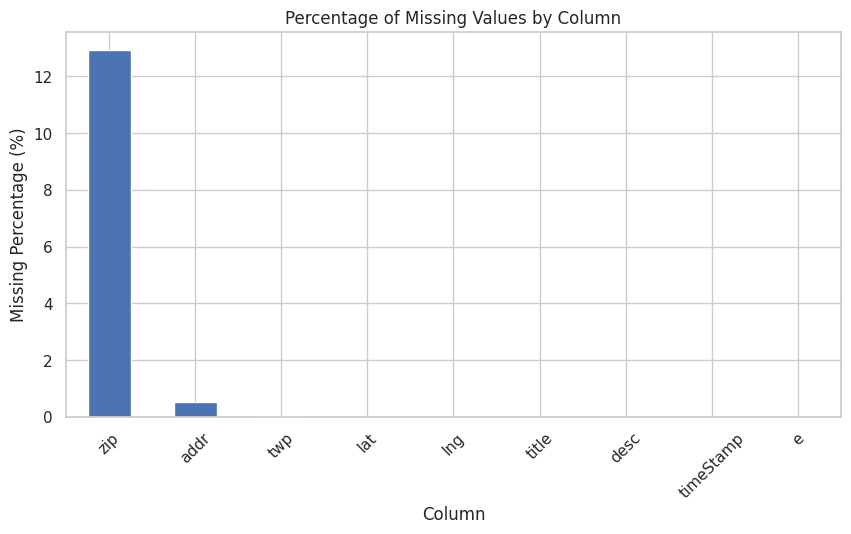

In [6]:
plt.figure(figsize=(10, 5))
missing_summary["missing_percent"].plot(kind="bar")
plt.title("Percentage of Missing Values by Column")
plt.ylabel("Missing Percentage (%)")
plt.xlabel("Column")
plt.xticks(rotation=45)
plt.show()

## 7. Check Duplicate Rows

### Request
Check whether the dataset contains duplicate rows.

### Why we do this
Duplicate rows can incorrectly increase counts and affect our analysis.

In [7]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


## 8. Clean Basic Columns

### Request
Drop the `e` column because it has only one value, and prepare a cleaned copy of the dataset.

### Why we do this
The `e` column is not useful for analysis because it does not contain meaningful variation.

In [8]:
df_clean = df.copy()

print("Unique values in e column:", df_clean["e"].unique())

df_clean = df_clean.drop(columns=["e"])
df_clean.head()

Unique values in e column: [1]


,lat,lng,desc,zip,title,timeStamp,twp,addr
0,40.30,-75.58,REINDEER CT & DEAD END; NEW HANOVER; Station ...,"19,525.00",EMS: BACK PAINS/INJURY,2015-12-10 17:40:00,NEW HANOVER,REINDEER CT & DEAD END
1,40.26,-75.26,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,"19,446.00",EMS: DIABETIC EMERGENCY,2015-12-10 17:40:00,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN
2,40.12,-75.35,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,"19,401.00",Fire: GAS-ODOR/LEAK,2015-12-10 17:40:00,NORRISTOWN,HAWS AVE
3,40.12,-75.34,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,"19,401.00",EMS: CARDIAC EMERGENCY,2015-12-10 17:40:01,NORRISTOWN,AIRY ST & SWEDE ST
4,40.25,-75.60,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 17:40:01,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END


## 9. Handle Missing Values Carefully

### Request
Fill missing categorical values with `"Unknown"` and keep `zip` as a nullable integer.

### Why we do this
For columns like `twp` and `addr`, missing values can be treated as unknown categories.  
For `zip`, we keep missing values but convert the column to Pandas nullable integer type so it looks cleaner.

In [9]:
df_clean["twp"] = df_clean["twp"].fillna("Unknown")
df_clean["addr"] = df_clean["addr"].fillna("Unknown")

df_clean["zip"] = df_clean["zip"].astype("Int64")

df_clean.isna().sum()

lat              0
lng              0
desc             0
zip          12855
title            0
timeStamp        0
twp              0
addr             0
dtype: int64

## 10. Convert `timeStamp` to Datetime

### Request
Convert the `timeStamp` column from text/object to datetime.

### Why we do this
Datetime format allows us to extract hour, month, day, date, and build time-based visualizations.

In [10]:
print("Before conversion:", df_clean["timeStamp"].dtype)

df_clean["timeStamp"] = pd.to_datetime(df_clean["timeStamp"])

print("After conversion:", df_clean["timeStamp"].dtype)
df_clean[["timeStamp"]].head()

Before conversion: object
After conversion: datetime64[ns]


,timeStamp
0,2015-12-10 17:40:00
1,2015-12-10 17:40:00
2,2015-12-10 17:40:00
3,2015-12-10 17:40:01
4,2015-12-10 17:40:01


## 11. Create Emergency Reason Feature

### Request
Create a new column called `Reason` from the part before `:` in the `title` column.

### Why we do this
The `title` column contains both the main emergency department and the specific call type.  
Example: `EMS: BACK PAINS/INJURY` → Reason = `EMS`.

In [11]:
df_clean["Reason"] = df_clean["title"].str.split(":").str[0]
df_clean[["title", "Reason"]].head()

,title,Reason
0,EMS: BACK PAINS/INJURY,EMS
1,EMS: DIABETIC EMERGENCY,EMS
2,Fire: GAS-ODOR/LEAK,Fire
3,EMS: CARDIAC EMERGENCY,EMS
4,EMS: DIZZINESS,EMS


## 12. Create Emergency Call Type Feature

### Request
Create a new column called `CallType` from the part after `:` in the `title` column.

### Why we do this
`Reason` gives the broad category, while `CallType` gives the more detailed emergency type.

In [12]:
df_clean["CallType"] = df_clean["title"].str.split(":").str[1].str.strip()
df_clean[["title", "Reason", "CallType"]].head()

,title,Reason,CallType
0,EMS: BACK PAINS/INJURY,EMS,BACK PAINS/INJURY
1,EMS: DIABETIC EMERGENCY,EMS,DIABETIC EMERGENCY
2,Fire: GAS-ODOR/LEAK,Fire,GAS-ODOR/LEAK
3,EMS: CARDIAC EMERGENCY,EMS,CARDIAC EMERGENCY
4,EMS: DIZZINESS,EMS,DIZZINESS


## 13. Create Time-Based Features

### Request
Create new columns: `Hour`, `Month`, `DayOfWeek`, `Date`, `Year`, `Weekend`, and `TimePeriod`.

### Why we do this
These features allow us to analyze call patterns by hour, day, month, weekend, and part of the day.

In [13]:
df_clean["Hour"] = df_clean["timeStamp"].dt.hour
df_clean["Month"] = df_clean["timeStamp"].dt.month
df_clean["Year"] = df_clean["timeStamp"].dt.year
df_clean["Date"] = df_clean["timeStamp"].dt.date
df_clean["DayOfWeek"] = df_clean["timeStamp"].dt.day_name().str[:3]

day_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
df_clean["DayOfWeek"] = pd.Categorical(df_clean["DayOfWeek"], categories=day_order, ordered=True)

df_clean["Weekend"] = df_clean["DayOfWeek"].isin(["Sat", "Sun"])

def get_time_period(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

df_clean["TimePeriod"] = df_clean["Hour"].apply(get_time_period)

df_clean.head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,Reason,CallType,Hour,Month,Year,Date,DayOfWeek,Weekend,TimePeriod
0,40.30,-75.58,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525,EMS: BACK PAINS/INJURY,2015-12-10 17:40:00,NEW HANOVER,REINDEER CT & DEAD END,EMS,BACK PAINS/INJURY,17,12,2015,2015-12-10,Thu,False,Evening
1,40.26,-75.26,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446,EMS: DIABETIC EMERGENCY,2015-12-10 17:40:00,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,EMS,DIABETIC EMERGENCY,17,12,2015,2015-12-10,Thu,False,Evening
2,40.12,-75.35,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401,Fire: GAS-ODOR/LEAK,2015-12-10 17:40:00,NORRISTOWN,HAWS AVE,Fire,GAS-ODOR/LEAK,17,12,2015,2015-12-10,Thu,False,Evening
3,40.12,-75.34,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401,EMS: CARDIAC EMERGENCY,2015-12-10 17:40:01,NORRISTOWN,AIRY ST & SWEDE ST,EMS,CARDIAC EMERGENCY,17,12,2015,2015-12-10,Thu,False,Evening
4,40.25,-75.60,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,<NA>,EMS: DIZZINESS,2015-12-10 17:40:01,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,EMS,DIZZINESS,17,12,2015,2015-12-10,Thu,False,Evening


# Basic Analysis Questions

## 14. What are the Top 5 Zip Codes for 911 Calls?

### Request
Find the top 5 zip codes with the highest number of 911 calls.

### Why we do this
This shows which zip code areas had the highest emergency call volume.

In [14]:
top_5_zip = df_clean["zip"].value_counts(dropna=True).head(5)
top_5_zip

zip
19401    6979
19464    6643
19403    4854
19446    4748
19406    3174
Name: count, dtype: Int64

## 15. Visualize Top 10 Zip Codes

### Request
Create a bar chart for the top 10 zip codes by number of calls.

### Why we do this
A bar chart makes it easier to compare high-call zip code areas.

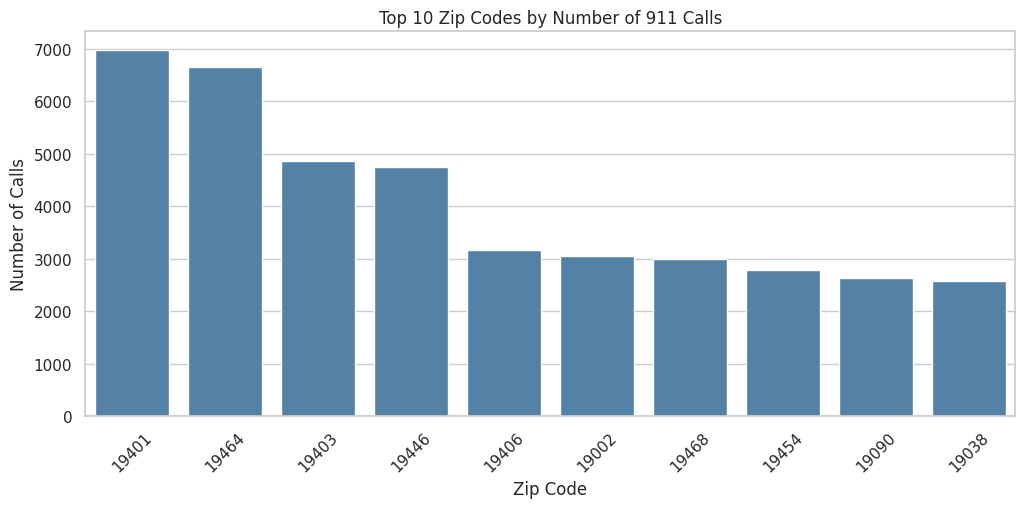

In [15]:
top_10_zip = df_clean["zip"].value_counts(dropna=True).head(10).reset_index()
top_10_zip.columns = ["zip", "call_count"]
top_10_zip["zip"] = top_10_zip["zip"].astype(str)

plt.figure(figsize=(12, 5))
sns.barplot(data=top_10_zip, x="zip", y="call_count", color="steelblue")
plt.title("Top 10 Zip Codes by Number of 911 Calls")
plt.xlabel("Zip Code")
plt.ylabel("Number of Calls")
plt.xticks(rotation=45)
plt.show()

## 16. What are the Top 5 Townships for 911 Calls?

### Request
Find the top 5 townships with the highest number of calls.

### Why we do this
This helps identify townships with the highest emergency activity.

In [16]:
top_5_twp = df_clean["twp"].value_counts().head(5)
top_5_twp

twp
LOWER MERION    8443
ABINGTON        5977
NORRISTOWN      5890
UPPER MERION    5227
CHELTENHAM      4575
Name: count, dtype: int64

## 17. Visualize Top 10 Townships

### Request
Create a horizontal bar chart of the top 10 townships.

### Why we do this
Horizontal bars work better when category names are longer.

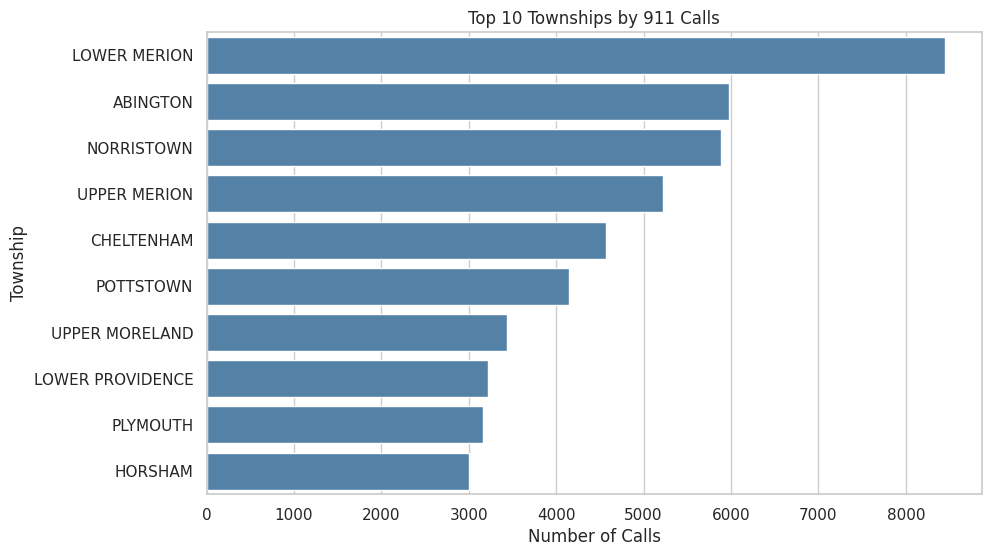

In [17]:
top_10_twp = df_clean["twp"].value_counts().head(10).reset_index()
top_10_twp.columns = ["township", "call_count"]

plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_twp, y="township", x="call_count", color="steelblue")
plt.title("Top 10 Townships by 911 Calls")
plt.xlabel("Number of Calls")
plt.ylabel("Township")
plt.show()

## 18. How Many Unique Emergency Titles Exist?

### Request
Count the number of unique values in the `title` column.

### Why we do this
This tells us how many different emergency title categories exist in the data.

In [18]:
unique_titles = df_clean["title"].nunique()
print("Number of unique emergency titles:", unique_titles)

Number of unique emergency titles: 110


## 19. What are the Most Common Emergency Titles?

### Request
Find the top 10 most common emergency titles.

### Why we do this
This shows the most frequent detailed emergency categories.

In [19]:
top_titles = df_clean["title"].value_counts().head(10)
top_titles

title
Traffic: VEHICLE ACCIDENT -    23066
Traffic: DISABLED VEHICLE -     7702
Fire: FIRE ALARM                5496
EMS: RESPIRATORY EMERGENCY      5112
EMS: CARDIAC EMERGENCY          5012
EMS: FALL VICTIM                4863
EMS: VEHICLE ACCIDENT           3935
Traffic: ROAD OBSTRUCTION -     3144
EMS: SUBJECT IN PAIN            2687
EMS: HEAD INJURY                2631
Name: count, dtype: int64

## 20. Visualize Most Common Call Types

### Request
Create a horizontal bar chart for the top 15 detailed call types.

### Why we do this
This gives more specific insight than only analyzing broad reasons like EMS, Fire, and Traffic.

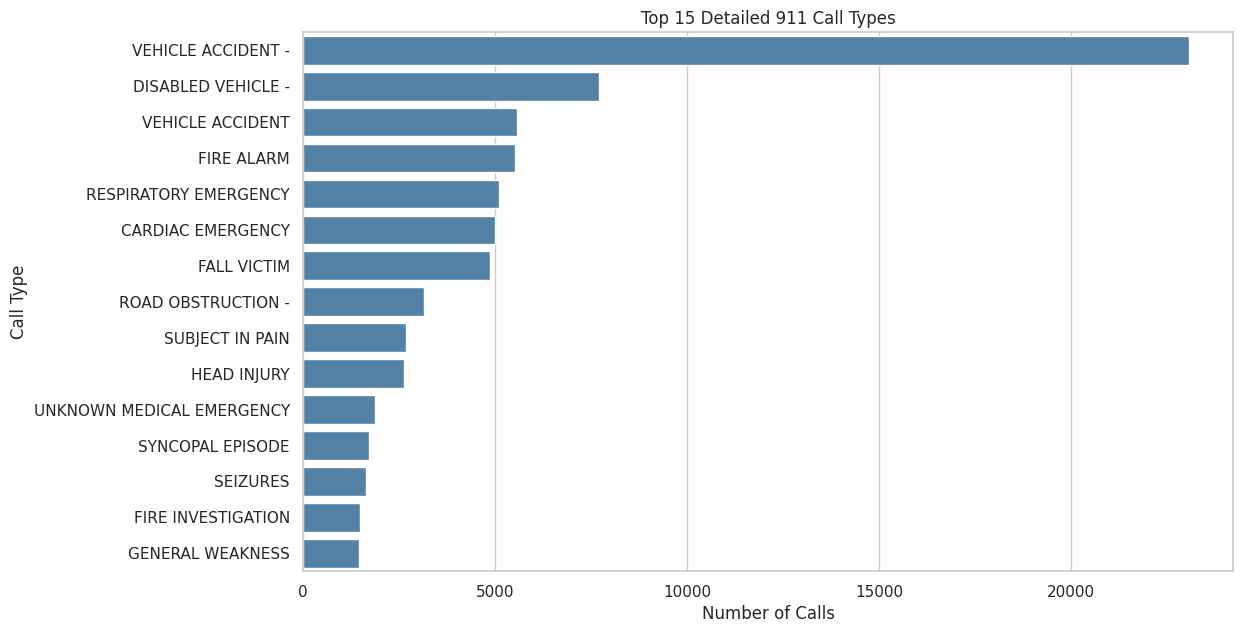

In [20]:
top_call_types = df_clean["CallType"].value_counts().head(15).reset_index()
top_call_types.columns = ["call_type", "call_count"]

plt.figure(figsize=(12, 7))
sns.barplot(data=top_call_types, y="call_type", x="call_count", color="steelblue")
plt.title("Top 15 Detailed 911 Call Types")
plt.xlabel("Number of Calls")
plt.ylabel("Call Type")
plt.show()

# Reason-Based Analysis

## 21. What is the Most Common Broad Reason for 911 Calls?

### Request
Count calls by `Reason`.

### Why we do this
This shows whether EMS, Fire, or Traffic calls are most common.

In [21]:
reason_counts = df_clean["Reason"].value_counts()
reason_counts

Reason
EMS        48877
Traffic    35695
Fire       14920
Name: count, dtype: int64

## 22. Visualize Calls by Reason

### Request
Create a countplot of 911 calls by reason.

### Why we do this
This is one of the most important summary charts for this dataset.

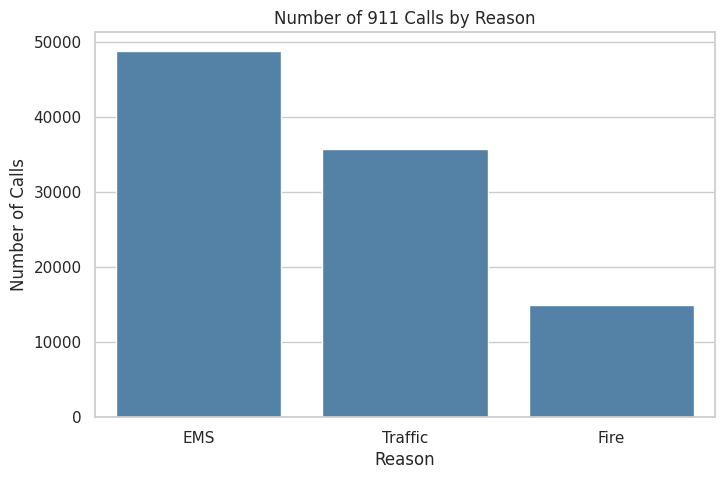

In [22]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x="Reason", order=reason_counts.index, color="steelblue")
plt.title("Number of 911 Calls by Reason")
plt.xlabel("Reason")
plt.ylabel("Number of Calls")
plt.show()

## 23. Calculate Percentage of Calls by Reason

### Request
Calculate the percentage share of each emergency reason.

### Why we do this
Raw counts are useful, but percentages make it easier to understand the distribution.

In [23]:
reason_percent = (df_clean["Reason"].value_counts(normalize=True) * 100).round(2)
reason_percent

Reason
EMS       49.13
Traffic   35.88
Fire      15.00
Name: proportion, dtype: float64

## 24. Compare Top Call Types Inside Each Reason

### Request
Find the top 5 detailed call types for each broad reason.

### Why we do this
EMS, Fire, and Traffic have different internal patterns. This shows the most common detailed emergencies inside each category.

In [24]:
top_types_by_reason = (
    df_clean
    .groupby("Reason")["CallType"]
    .value_counts()
    .groupby(level=0)
    .head(5)
)

top_types_by_reason

Reason   CallType                   
EMS      RESPIRATORY EMERGENCY           5112
         CARDIAC EMERGENCY               5012
         FALL VICTIM                     4863
         VEHICLE ACCIDENT                3935
         SUBJECT IN PAIN                 2687
Fire     FIRE ALARM                      5496
         VEHICLE ACCIDENT                1638
         FIRE INVESTIGATION              1460
         GAS-ODOR/LEAK                   1028
         BUILDING FIRE                    807
Traffic  VEHICLE ACCIDENT -             23066
         DISABLED VEHICLE -              7702
         ROAD OBSTRUCTION -              3144
         HAZARDOUS ROAD CONDITIONS -     1086
         VEHICLE FIRE -                   553
Name: count, dtype: int64

## 25. Visualize Top Call Types by Reason

### Request
Create separate bar charts showing the top 10 call types for EMS, Fire, and Traffic.

### Why we do this
Separate charts are easier to read than one crowded chart.

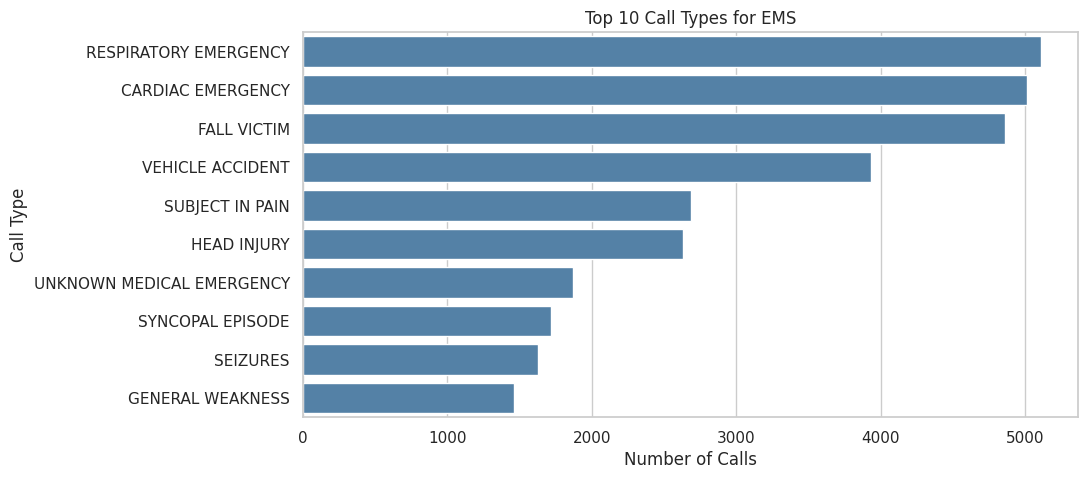

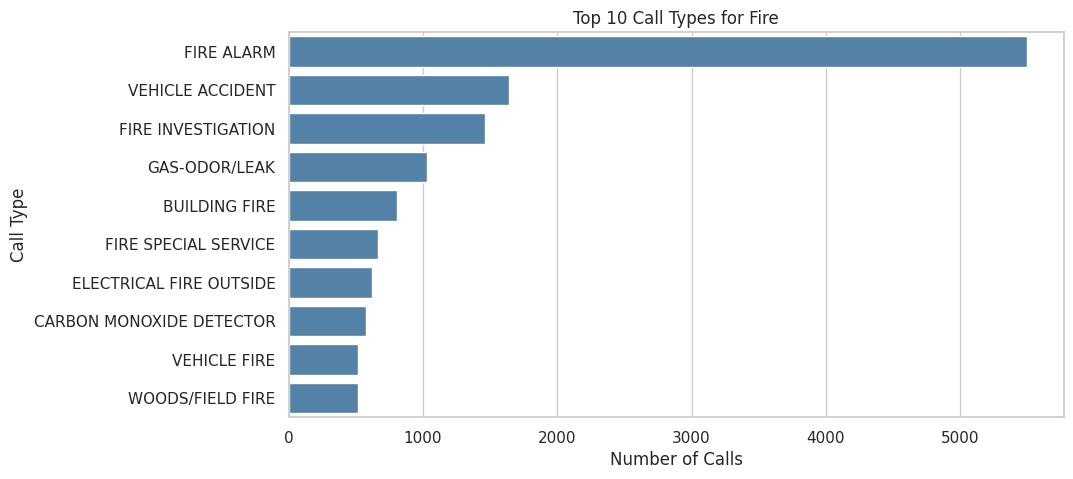

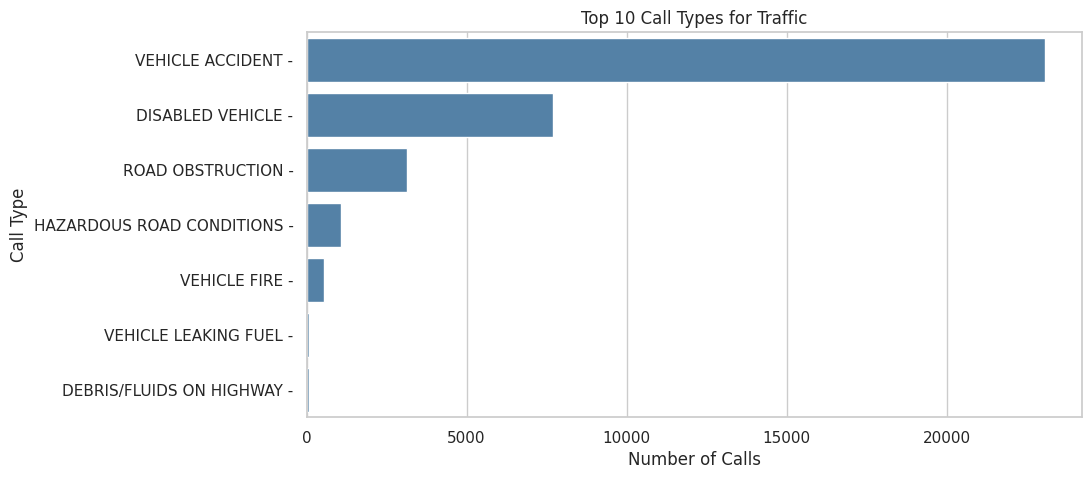

In [25]:
for reason in df_clean["Reason"].unique():
    temp = df_clean[df_clean["Reason"] == reason]["CallType"].value_counts().head(10).reset_index()
    temp.columns = ["call_type", "call_count"]

    plt.figure(figsize=(10, 5))
    sns.barplot(data=temp, y="call_type", x="call_count", color="steelblue")
    plt.title(f"Top 10 Call Types for {reason}")
    plt.xlabel("Number of Calls")
    plt.ylabel("Call Type")
    plt.show()

# Time-Based Analysis

## 26. What is the Date Range of the Dataset?

### Request
Find the minimum and maximum timestamp.

### Why we do this
Before analyzing time trends, we need to know the time period covered by the data.

In [26]:
print("First call:", df_clean["timeStamp"].min())
print("Last call:", df_clean["timeStamp"].max())

First call: 2015-12-10 17:40:00
Last call: 2016-08-24 11:17:02


## 27. Calls by Month

### Request
Count the number of calls in each month.

### Why we do this
Monthly analysis helps us see whether call volume changes over time.

In [27]:
calls_by_month = df_clean.groupby("Month").size()
calls_by_month

Month
1     13205
2     11467
3     11101
4     11326
5     11423
6     11786
7     12137
8      9078
12     7969
dtype: int64

## 28. Visualize Calls by Month

### Request
Create a line plot showing the number of calls per month.

### Why we do this
A line plot is useful for seeing time trends and missing months.

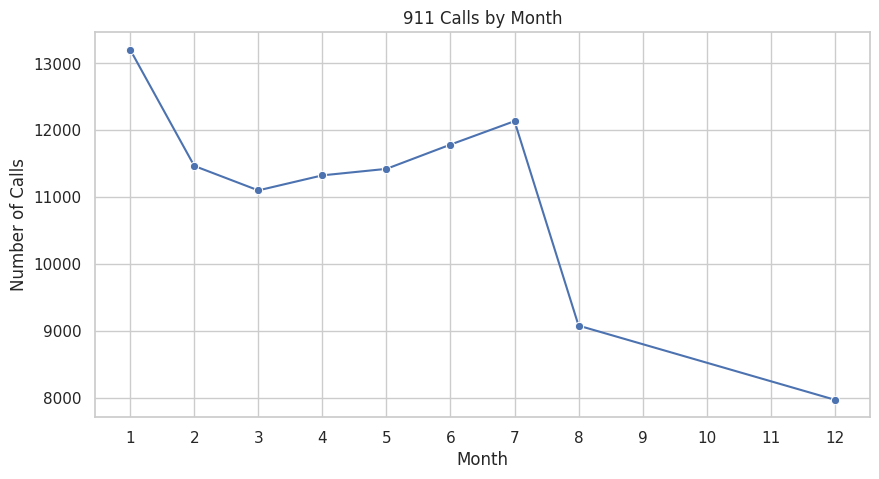

In [28]:
calls_by_month_df = calls_by_month.reset_index(name="call_count")

plt.figure(figsize=(10, 5))
sns.lineplot(data=calls_by_month_df, x="Month", y="call_count", marker="o")
plt.title("911 Calls by Month")
plt.xlabel("Month")
plt.ylabel("Number of Calls")
plt.xticks(range(1, 13))
plt.show()

## 29. Calls by Month and Reason

### Request
Compare monthly call volume for each reason.

### Why we do this
This shows whether EMS, Fire, and Traffic follow the same monthly pattern or behave differently.

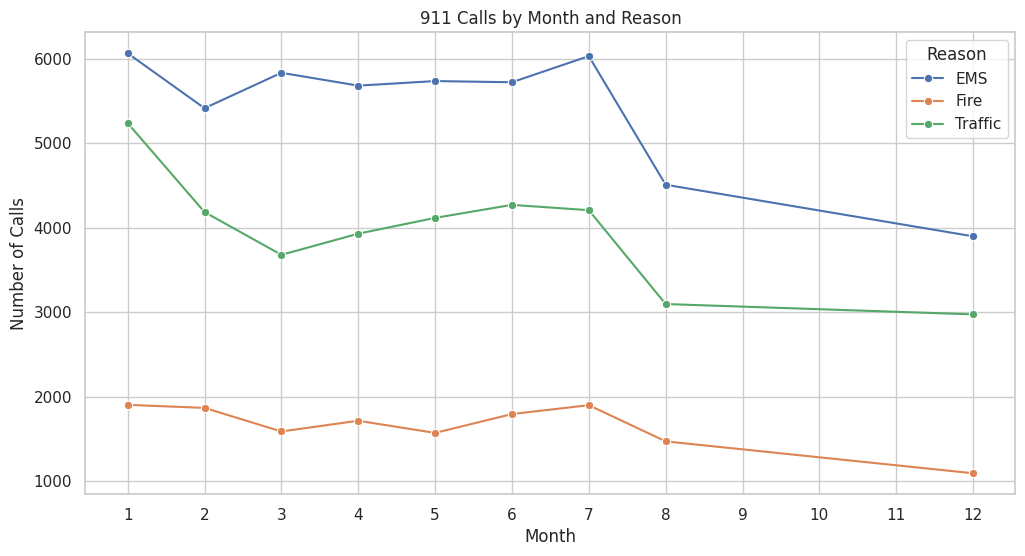

In [29]:
monthly_reason = (
    df_clean
    .groupby(["Month", "Reason"])
    .size()
    .reset_index(name="call_count")
)

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_reason, x="Month", y="call_count", hue="Reason", marker="o")
plt.title("911 Calls by Month and Reason")
plt.xlabel("Month")
plt.ylabel("Number of Calls")
plt.xticks(range(1, 13))
plt.show()

## 30. Calls by Day of Week

### Request
Count calls by day of week.

### Why we do this
This helps identify whether emergency calls are more common on weekdays or weekends.

In [30]:
calls_by_day = df_clean["DayOfWeek"].value_counts().sort_index()
calls_by_day

DayOfWeek
Mon    14680
Tue    15150
Wed    14879
Thu    14478
Fri    14833
Sat    13336
Sun    12136
Name: count, dtype: int64

## 31. Visualize Calls by Day of Week and Reason

### Request
Create a countplot of day of week with `Reason` as hue.

### Why we do this
This allows us to compare daily patterns across EMS, Fire, and Traffic calls.

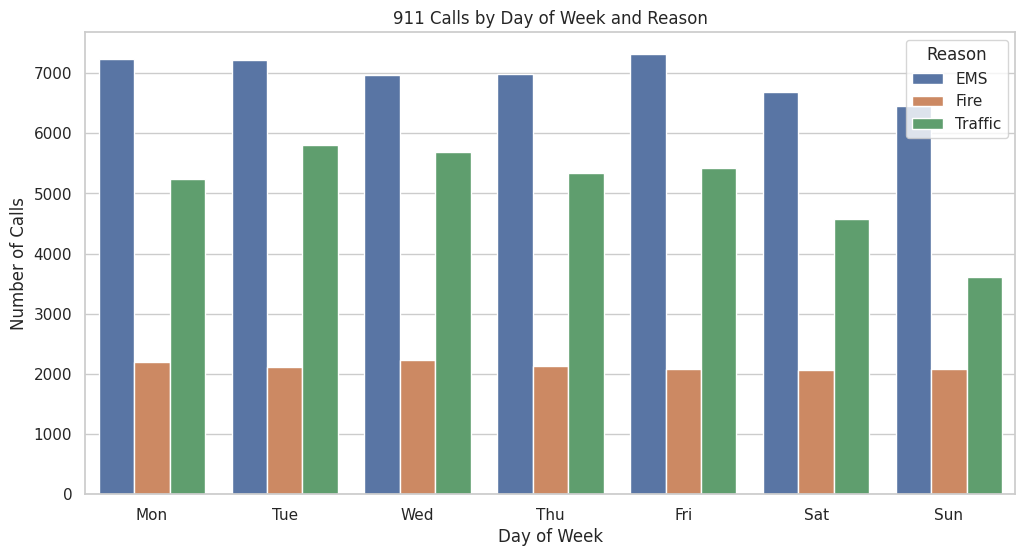

In [31]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_clean, x="DayOfWeek", hue="Reason", order=day_order)
plt.title("911 Calls by Day of Week and Reason")
plt.xlabel("Day of Week")
plt.ylabel("Number of Calls")
plt.legend(title="Reason")
plt.show()

## 32. Calls by Hour

### Request
Count calls by hour of the day.

### Why we do this
Hourly analysis helps identify peak emergency call times.

In [32]:
calls_by_hour = df_clean.groupby("Hour").size().reset_index(name="call_count")
calls_by_hour.head()

,Hour,call_count
0,0,2112
1,1,1721
2,2,1549
3,3,1435
4,4,1418


## 33. Visualize Calls by Hour

### Request
Create a line plot showing calls by hour.

### Why we do this
This shows what time of day has the highest and lowest emergency call volume.

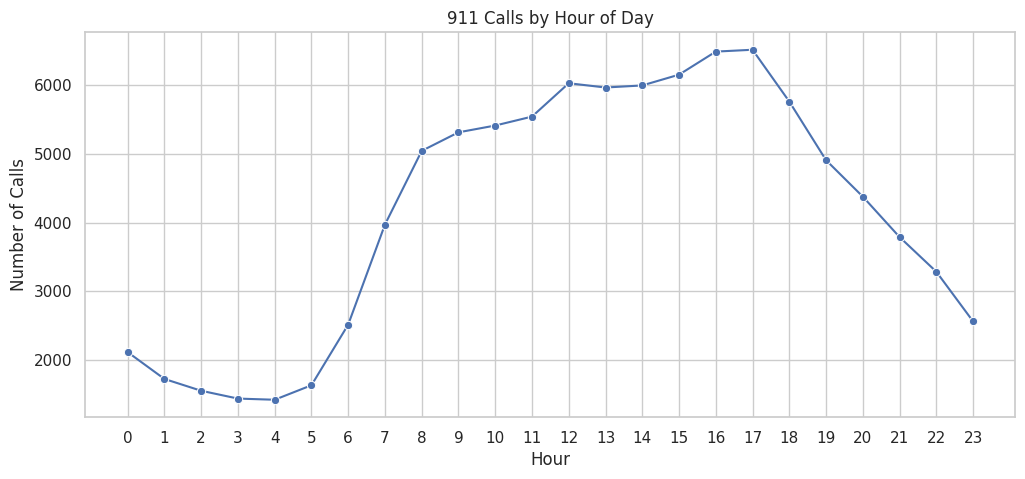

In [33]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=calls_by_hour, x="Hour", y="call_count", marker="o")
plt.title("911 Calls by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Calls")
plt.xticks(range(0, 24))
plt.show()

## 34. Calls by Time Period

### Request
Count calls by `TimePeriod`: Morning, Afternoon, Evening, and Night.

### Why we do this
This simplifies the hourly data into easier-to-understand categories.

In [34]:
period_order = ["Morning", "Afternoon", "Evening", "Night"]

time_period_counts = df_clean["TimePeriod"].value_counts().reindex(period_order)
time_period_counts

TimePeriod
Morning      29426
Afternoon    30637
Evening      21564
Night        17865
Name: count, dtype: int64

## 35. Visualize Calls by Time Period and Reason

### Request
Create a countplot of `TimePeriod` with `Reason` as hue.

### Why we do this
This helps compare when different types of emergencies happen during the day.

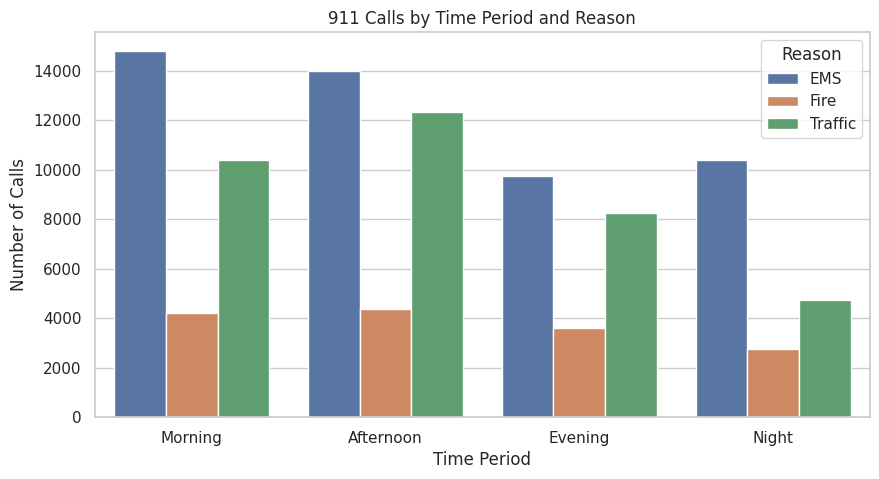

In [35]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df_clean, x="TimePeriod", hue="Reason", order=period_order)
plt.title("911 Calls by Time Period and Reason")
plt.xlabel("Time Period")
plt.ylabel("Number of Calls")
plt.show()

## 36. Weekday vs Weekend Calls

### Request
Compare total calls on weekdays and weekends.

### Why we do this
This checks whether emergency call volume changes during the weekend.

In [36]:
weekend_counts = df_clean["Weekend"].value_counts().rename(index={False: "Weekday", True: "Weekend"})
weekend_counts

Weekend
Weekday    74020
Weekend    25472
Name: count, dtype: int64

## 37. Visualize Weekday vs Weekend by Reason

### Request
Create a countplot comparing weekday/weekend calls by reason.

### Why we do this
Traffic and emergency patterns may differ between weekdays and weekends.

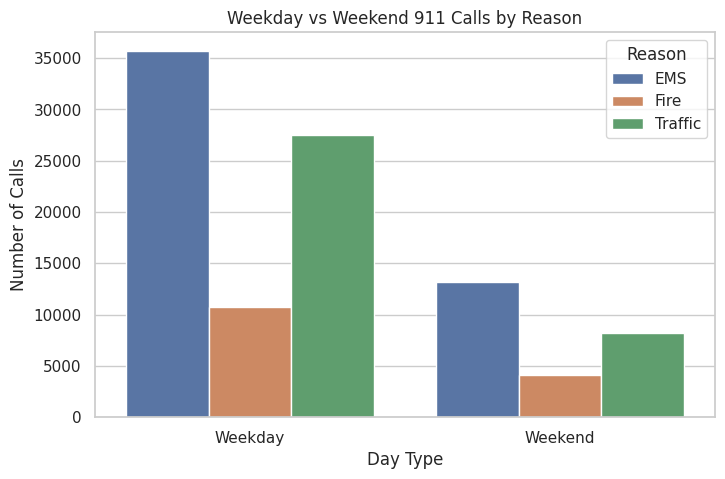

In [37]:
weekend_plot_df = df_clean.copy()
weekend_plot_df["DayType"] = np.where(weekend_plot_df["Weekend"], "Weekend", "Weekday")

plt.figure(figsize=(8, 5))
sns.countplot(data=weekend_plot_df, x="DayType", hue="Reason", order=["Weekday", "Weekend"])
plt.title("Weekday vs Weekend 911 Calls by Reason")
plt.xlabel("Day Type")
plt.ylabel("Number of Calls")
plt.show()

# Daily Trend Analysis

## 38. Calls by Date

### Request
Group calls by exact date and plot the daily call trend.

### Why we do this
Daily trends show short-term spikes and drops that monthly charts can hide.

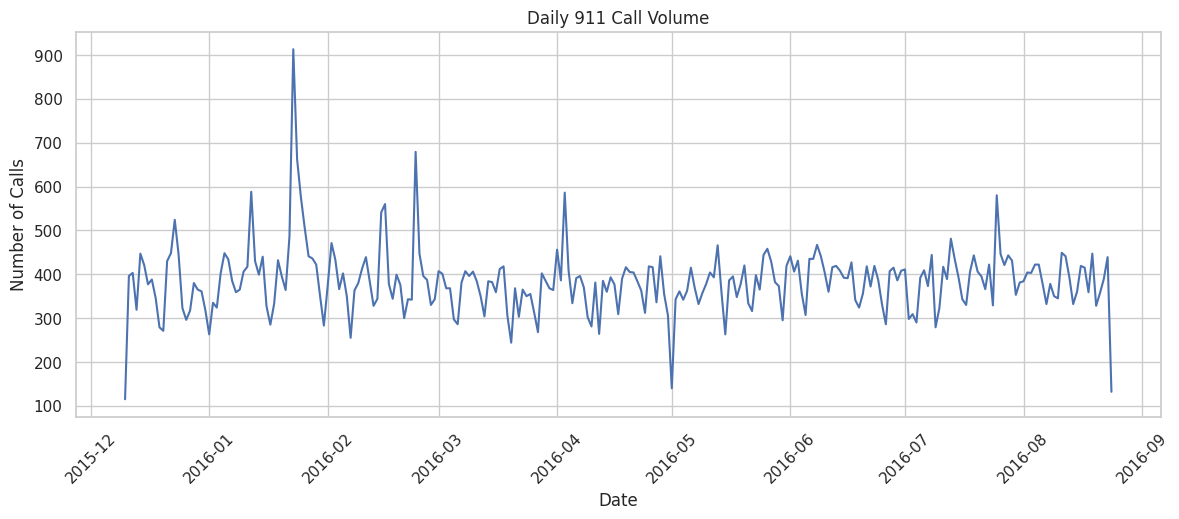

,Date,call_count
0,2015-12-10,115
1,2015-12-11,396
2,2015-12-12,403
3,2015-12-13,319
4,2015-12-14,447


In [38]:
daily_calls = df_clean.groupby("Date").size().reset_index(name="call_count")

plt.figure(figsize=(14, 5))
sns.lineplot(data=daily_calls, x="Date", y="call_count")
plt.title("Daily 911 Call Volume")
plt.xlabel("Date")
plt.ylabel("Number of Calls")
plt.xticks(rotation=45)
plt.show()

daily_calls.head()

## 39. Daily Calls by Reason

### Request
Create one daily line plot for each reason.

### Why we do this
This helps us compare daily trends separately for EMS, Fire, and Traffic.

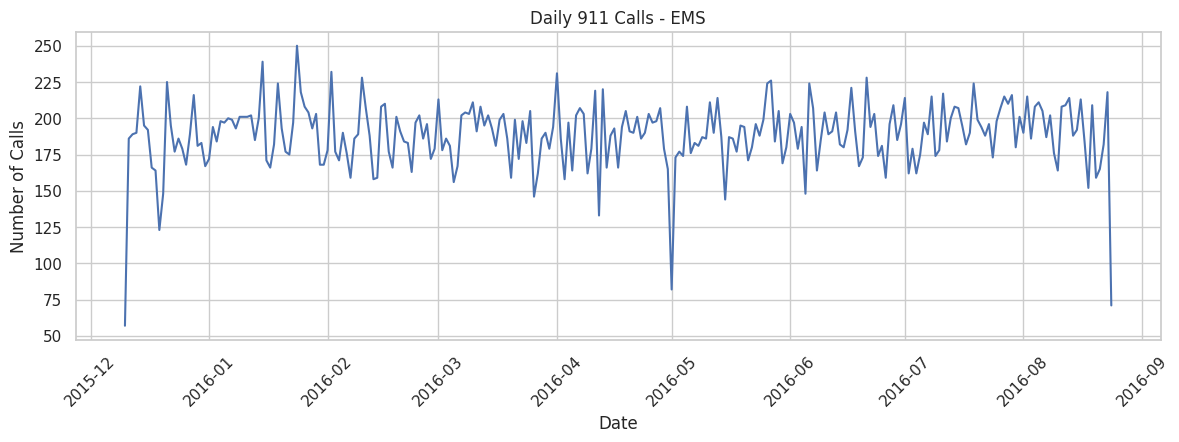

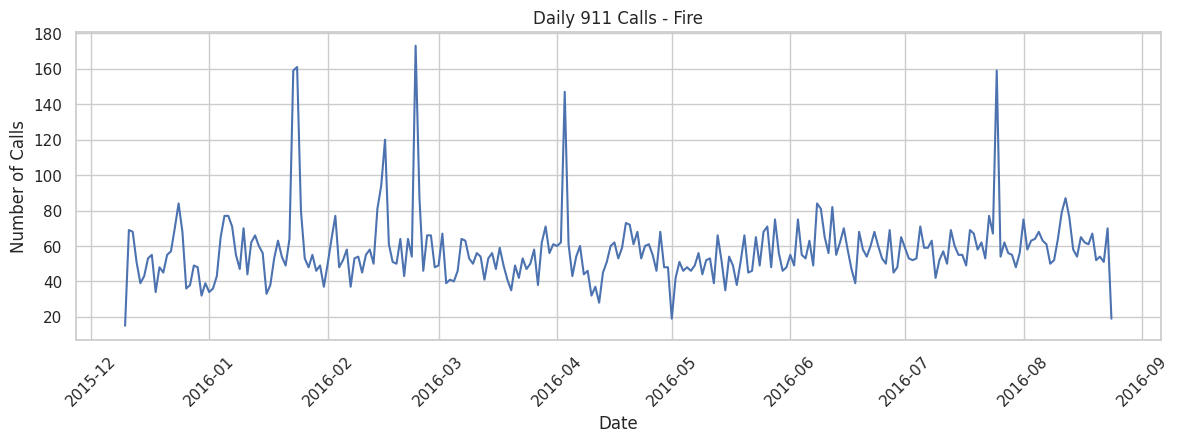

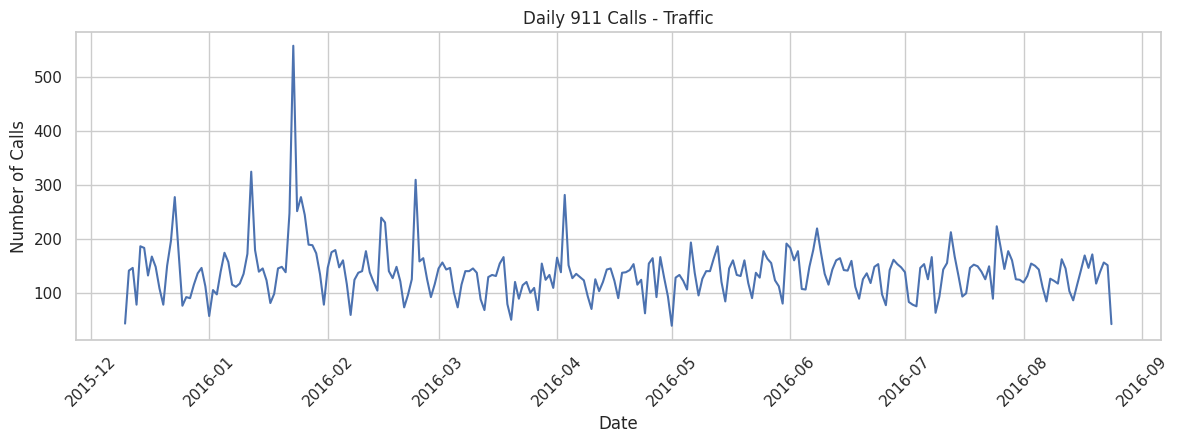

In [39]:
for reason in df_clean["Reason"].unique():
    temp = (
        df_clean[df_clean["Reason"] == reason]
        .groupby("Date")
        .size()
        .reset_index(name="call_count")
    )

    plt.figure(figsize=(14, 4))
    sns.lineplot(data=temp, x="Date", y="call_count")
    plt.title(f"Daily 911 Calls - {reason}")
    plt.xlabel("Date")
    plt.ylabel("Number of Calls")
    plt.xticks(rotation=45)
    plt.show()

## 40. Add 7-Day Moving Average

### Request
Calculate a 7-day moving average for daily calls.

### Why we do this
Moving averages smooth noisy daily data and make the general trend easier to see.

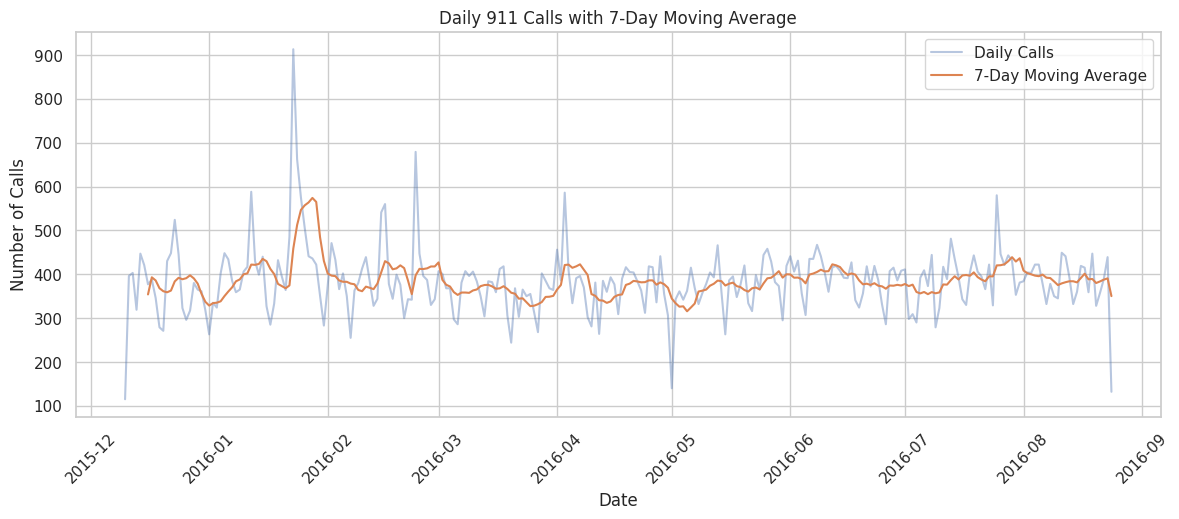

In [40]:
daily_calls["moving_avg_7"] = daily_calls["call_count"].rolling(window=7).mean()

plt.figure(figsize=(14, 5))
sns.lineplot(data=daily_calls, x="Date", y="call_count", label="Daily Calls", alpha=0.4)
sns.lineplot(data=daily_calls, x="Date", y="moving_avg_7", label="7-Day Moving Average")
plt.title("Daily 911 Calls with 7-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Number of Calls")
plt.xticks(rotation=45)
plt.legend()
plt.show()

# Heatmaps and Pivot Tables

## 41. Create Day of Week vs Hour Pivot Table

### Request
Create a pivot table where rows are days of week, columns are hours, and values are call counts.

### Why we do this
This prepares the data for a heatmap showing when calls are most frequent.

In [41]:
day_hour_pivot = df_clean.pivot_table(
    index="DayOfWeek",
    columns="Hour",
    values="title",
    aggfunc="count"
)

day_hour_pivot

/tmp/ipykernel_3489/3705722876.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  day_hour_pivot = df_clean.pivot_table(


Hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
DayOfWeek,,,,,,,,,,,,,,,,,,,,,,,,
Mon,282,221,201,194,204,267,397,653,819,786,793,822,893,842,869,913,989,997,885,746,613,497,472,325
Tue,269,240,186,170,209,239,415,655,889,880,840,838,887,917,943,938,1026,1019,905,731,647,571,462,274
Wed,250,216,189,209,156,255,410,701,875,808,800,789,903,872,904,867,990,1037,894,686,668,575,490,335
Thu,278,202,233,159,182,203,362,570,777,828,837,773,889,936,876,969,935,1013,810,698,617,553,424,354
Fri,275,235,191,175,201,194,372,598,742,752,803,859,885,890,932,980,1039,980,820,696,667,559,514,474
Sat,375,301,263,260,224,231,257,391,459,640,697,769,801,831,789,796,848,757,778,696,628,572,506,467
Sun,383,306,286,268,242,240,300,402,483,620,643,693,771,679,684,691,663,714,670,655,537,461,415,330


## 42. Heatmap: Day of Week vs Hour

### Request
Create a heatmap from the day-hour pivot table.

### Why we do this
A heatmap quickly shows peak call periods across the week and day.

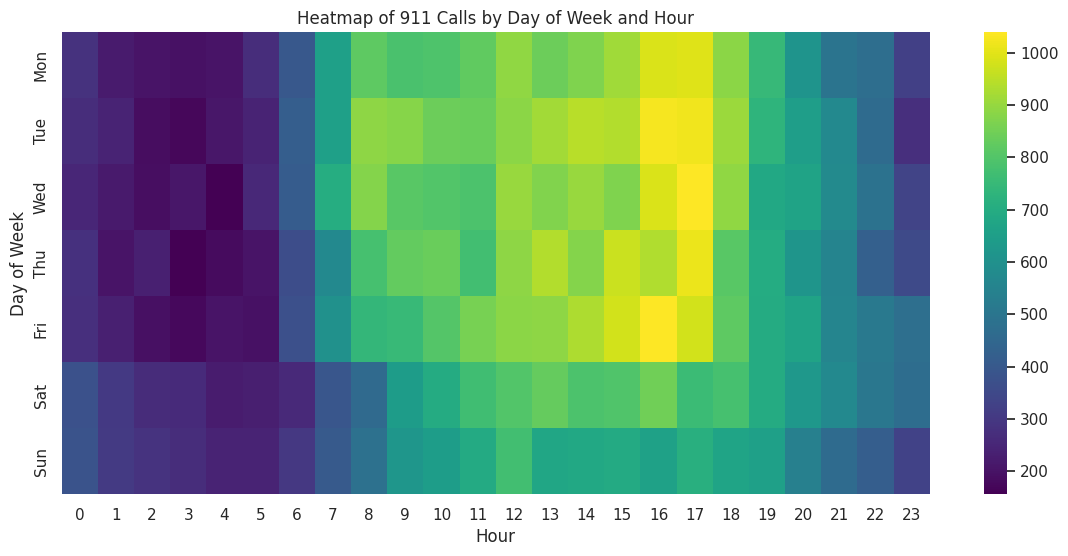

In [42]:
plt.figure(figsize=(14, 6))
sns.heatmap(day_hour_pivot, cmap="viridis")
plt.title("Heatmap of 911 Calls by Day of Week and Hour")
plt.xlabel("Hour")
plt.ylabel("Day of Week")
plt.show()

## 43. Clustermap: Day of Week vs Hour

### Request
Create a clustermap using the same day-hour pivot table.

### Why we do this
A clustermap groups similar days/hours based on call patterns.

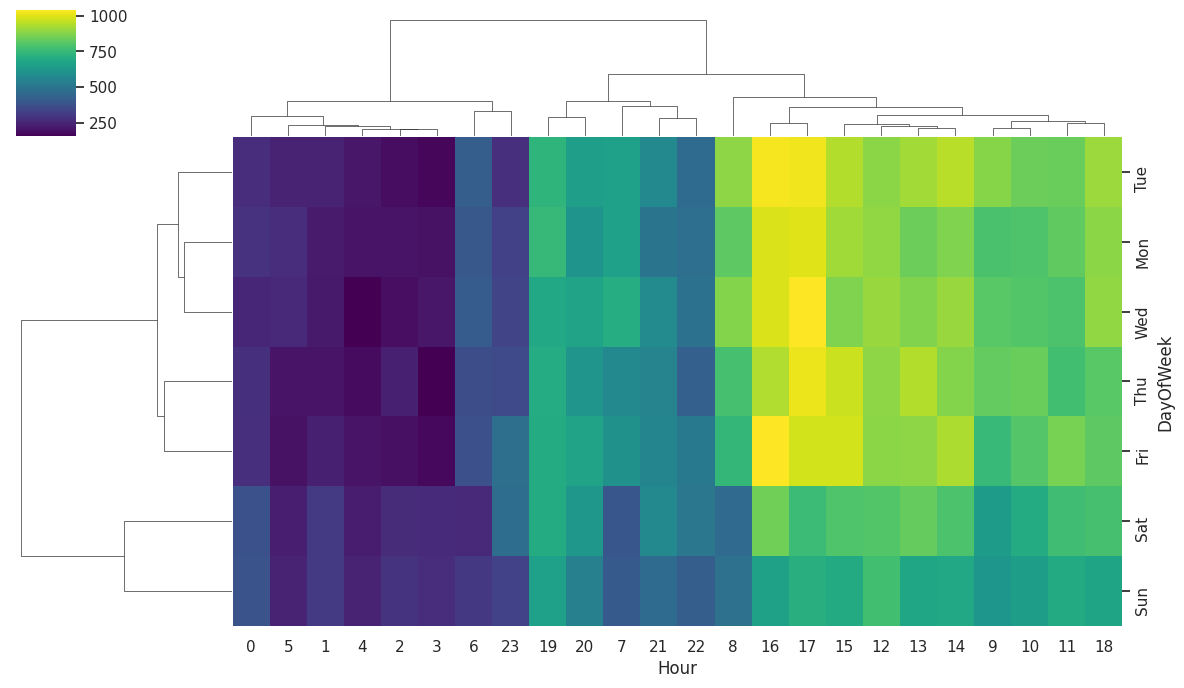

In [43]:
sns.clustermap(day_hour_pivot, cmap="viridis", figsize=(12, 7))
plt.show()

## 44. Create Month vs Hour Pivot Table

### Request
Create a pivot table where rows are months, columns are hours, and values are call counts.

### Why we do this
This shows how hourly call patterns change by month.

In [44]:
month_hour_pivot = df_clean.pivot_table(
    index="Month",
    columns="Hour",
    values="title",
    aggfunc="count"
)

month_hour_pivot

Hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
Month,,,,,,,,,,,,,,,,,,,,,,,,
1,294,218,225,205,205,214,386,551,755,752,660,775,788,765,775,691,725,871,798,687,592,507,421,345
2,267,194,161,149,161,213,325,550,597,603,620,582,634,698,648,704,692,674,693,578,518,453,426,327
3,214,181,194,149,152,181,291,487,556,614,649,612,648,662,672,707,782,676,600,547,493,402,359,273
4,243,204,170,161,179,178,316,482,613,598,607,609,725,694,705,728,767,728,646,533,472,377,309,282
5,255,195,158,173,160,196,254,439,605,644,584,709,721,672,640,746,728,787,608,510,489,462,405,283
6,229,192,168,157,148,172,290,436,565,630,637,667,777,726,726,767,817,769,693,563,496,456,399,306
7,241,224,181,188,177,196,279,431,545,635,645,636,738,729,791,744,815,826,675,652,583,481,433,292
8,219,182,166,135,131,144,188,326,466,465,578,519,522,548,552,612,656,564,476,419,373,345,245,247
12,150,131,126,118,105,135,184,268,342,373,433,434,476,473,488,455,508,622,573,419,361,305,286,204


## 45. Heatmap: Month vs Hour

### Request
Create a heatmap from the month-hour pivot table.

### Why we do this
This helps identify whether some months have stronger activity during specific hours.

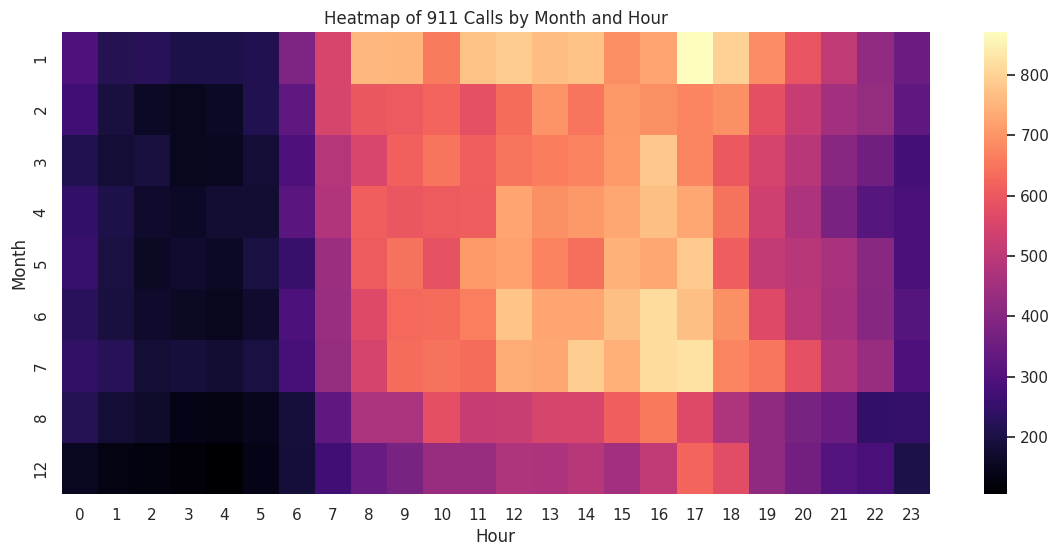

In [45]:
plt.figure(figsize=(14, 6))
sns.heatmap(month_hour_pivot, cmap="magma")
plt.title("Heatmap of 911 Calls by Month and Hour")
plt.xlabel("Hour")
plt.ylabel("Month")
plt.show()

## 46. Create Day of Week vs Month Pivot Table

### Request
Create a pivot table where rows are days of week and columns are months.

### Why we do this
This helps compare weekly patterns across months.

In [46]:
day_month_pivot = df_clean.pivot_table(
    index="DayOfWeek",
    columns="Month",
    values="title",
    aggfunc="count"
)

day_month_pivot

/tmp/ipykernel_3489/2256012259.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  day_month_pivot = df_clean.pivot_table(


Month,1,2,3,4,5,6,7,8,12
DayOfWeek,,,,,,,,,
Mon,1727,1964,1535,1598,1779,1617,1692,1511,1257
Tue,1973,1753,1884,1430,1918,1676,1670,1612,1234
Wed,1700,1903,1889,1517,1538,2058,1717,1295,1262
Thu,1584,1596,1900,1601,1590,2065,1646,1230,1266
Fri,1970,1581,1525,1958,1730,1649,2045,1310,1065
Sat,2291,1441,1266,1734,1444,1388,1695,1099,978
Sun,1960,1229,1102,1488,1424,1333,1672,1021,907


## 47. Heatmap: Day of Week vs Month

### Request
Create a heatmap using day of week and month.

### Why we do this
This shows whether certain months and weekdays had higher emergency call counts.

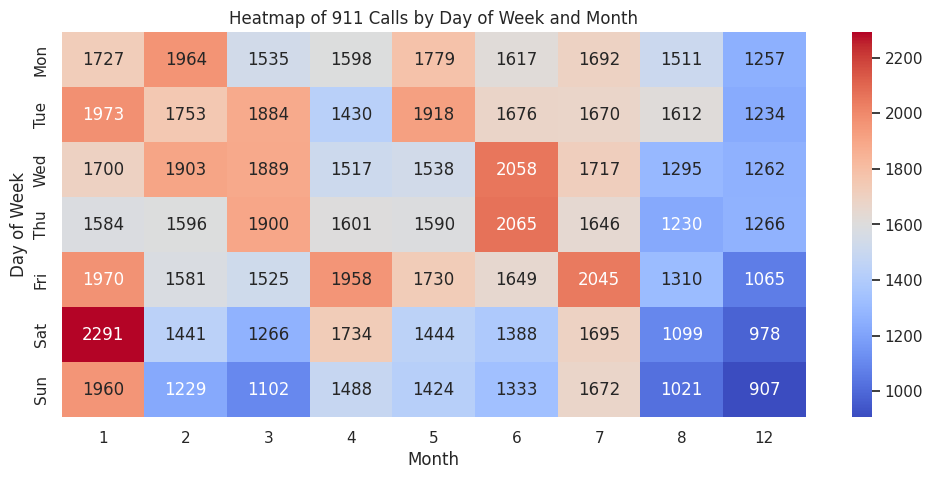

In [47]:
plt.figure(figsize=(12, 5))
sns.heatmap(day_month_pivot, cmap="coolwarm", annot=True, fmt=".0f")
plt.title("Heatmap of 911 Calls by Day of Week and Month")
plt.xlabel("Month")
plt.ylabel("Day of Week")
plt.show()

# Location-Based Analysis

## 48. Basic Latitude and Longitude Summary

### Request
Check descriptive statistics for latitude and longitude.

### Why we do this
This helps us understand the geographic range of the emergency calls.

In [48]:
df_clean[["lat", "lng"]].describe()

,lat,lng
count,"99,492.00","99,492.00"
mean,40.16,-75.32
std,0.09,0.17
min,30.33,-95.60
25%,40.10,-75.39
50%,40.15,-75.30
75%,40.23,-75.21
max,41.17,-75.00


## 49. Scatter Plot of Call Locations

### Request
Create a scatter plot using longitude and latitude.

### Why we do this
This gives a simple geographic view of where 911 calls are concentrated.

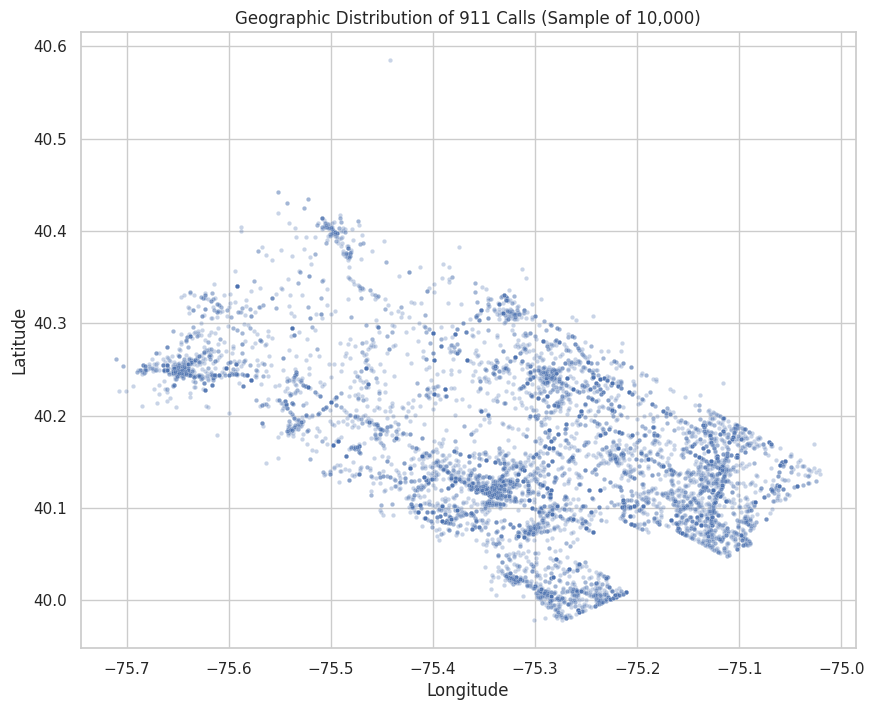

In [49]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_clean.sample(10000, random_state=42),
    x="lng",
    y="lat",
    alpha=0.3,
    s=10
)
plt.title("Geographic Distribution of 911 Calls (Sample of 10,000)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

## 50. Scatter Plot of Call Locations by Reason

### Request
Create a scatter plot of locations colored by reason.

### Why we do this
This helps check whether EMS, Fire, and Traffic calls appear in different geographic areas.

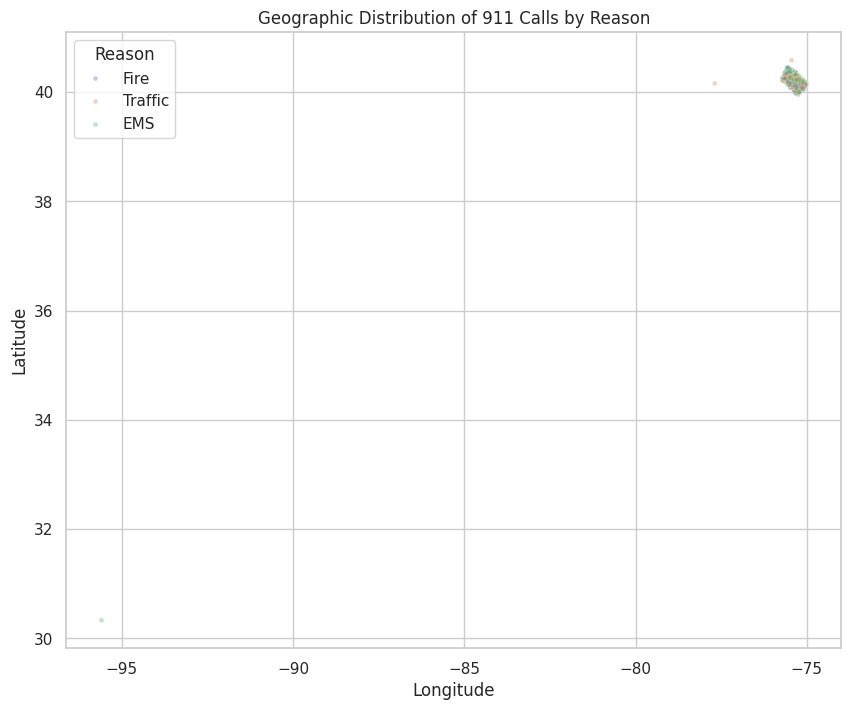

In [50]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_clean.sample(15000, random_state=42),
    x="lng",
    y="lat",
    hue="Reason",
    alpha=0.35,
    s=12
)
plt.title("Geographic Distribution of 911 Calls by Reason")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Reason")
plt.show()

# Deeper Analytical Questions

## 51. Which Township Has the Highest Number of Calls for Each Reason?

### Request
Find the top township separately for EMS, Fire, and Traffic.

### Why we do this
The overall top township may not be the top township for every emergency reason.

In [51]:
top_township_by_reason = (
    df_clean
    .groupby(["Reason", "twp"])
    .size()
    .reset_index(name="call_count")
    .sort_values(["Reason", "call_count"], ascending=[True, False])
    .groupby("Reason")
    .head(1)
)

top_township_by_reason

,Reason,twp,call_count
35,EMS,NORRISTOWN,3858
95,Fire,LOWER MERION,1548
164,Traffic,LOWER MERION,3724


## 52. Top 10 Townships by Reason

### Request
Create a grouped table of top townships for each reason.

### Why we do this
This gives a more detailed township-level view for EMS, Fire, and Traffic.

In [52]:
top_10_twp_reason = (
    df_clean
    .groupby(["Reason", "twp"])
    .size()
    .reset_index(name="call_count")
    .sort_values(["Reason", "call_count"], ascending=[True, False])
    .groupby("Reason")
    .head(10)
)

top_10_twp_reason

,Reason,twp,call_count
35,EMS,NORRISTOWN,3858
26,EMS,LOWER MERION,3171
0,EMS,ABINGTON,3043
41,EMS,POTTSTOWN,2635
6,EMS,CHELTENHAM,2098
57,EMS,UPPER MERION,2065
29,EMS,LOWER PROVIDENCE,2026
58,EMS,UPPER MORELAND,1733
19,EMS,HORSHAM,1324
40,EMS,PLYMOUTH,1274


## 53. Visualize Top Townships by Reason

### Request
Create bar charts for the top 10 townships inside each reason.

### Why we do this
This makes it easier to compare township call counts within each broad emergency category.

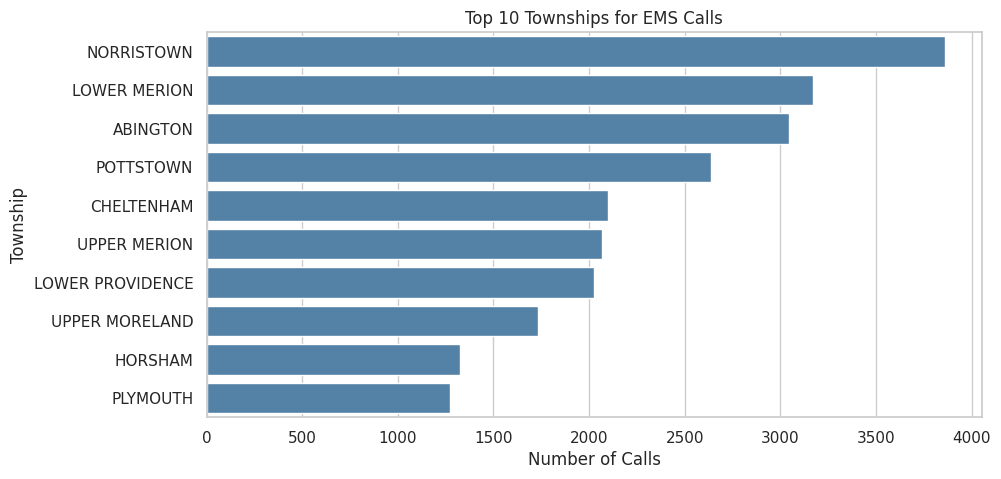

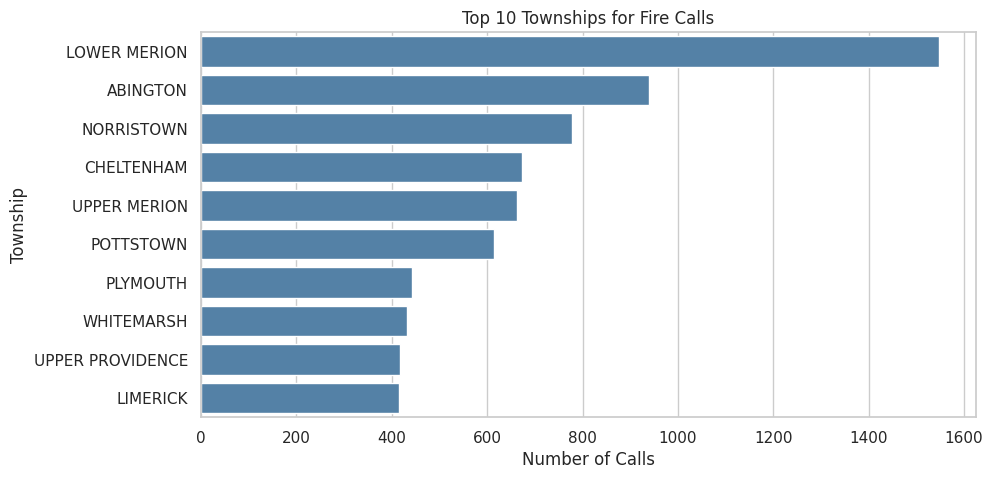

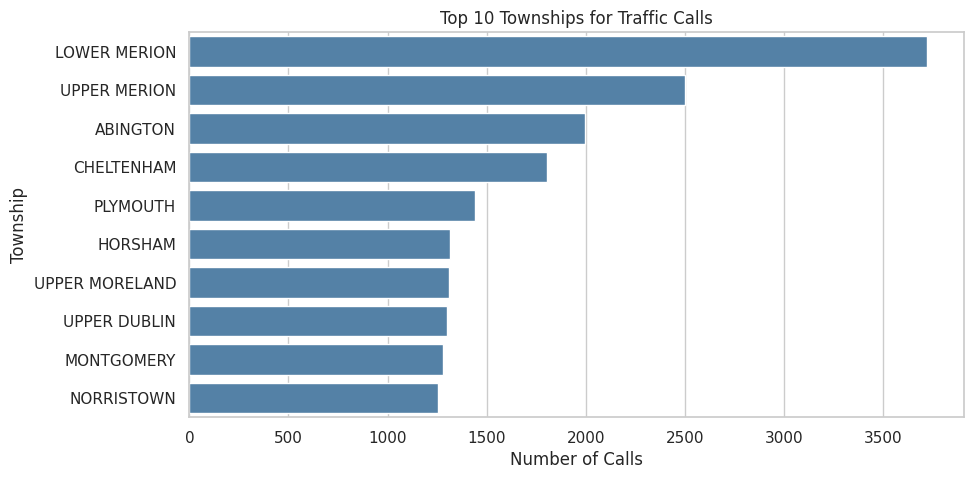

In [53]:
for reason in df_clean["Reason"].unique():
    temp = top_10_twp_reason[top_10_twp_reason["Reason"] == reason]

    plt.figure(figsize=(10, 5))
    sns.barplot(data=temp, y="twp", x="call_count", color="steelblue")
    plt.title(f"Top 10 Townships for {reason} Calls")
    plt.xlabel("Number of Calls")
    plt.ylabel("Township")
    plt.show()

## 54. Which Hours Are the Busiest for Each Reason?

### Request
Find call counts by hour and reason.

### Why we do this
EMS, Fire, and Traffic may have different peak hours.

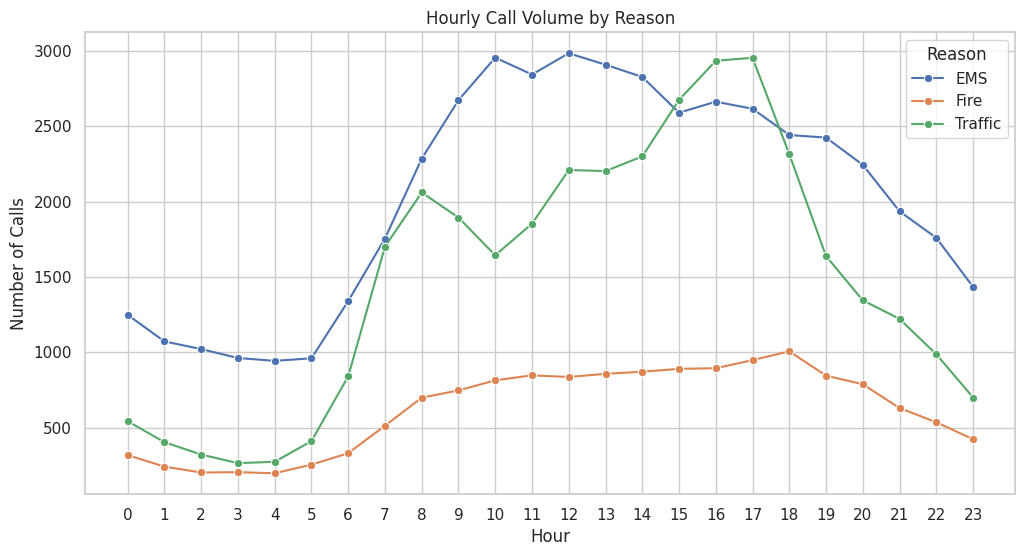

In [54]:
hour_reason = (
    df_clean
    .groupby(["Hour", "Reason"])
    .size()
    .reset_index(name="call_count")
)

plt.figure(figsize=(12, 6))
sns.lineplot(data=hour_reason, x="Hour", y="call_count", hue="Reason", marker="o")
plt.title("Hourly Call Volume by Reason")
plt.xlabel("Hour")
plt.ylabel("Number of Calls")
plt.xticks(range(0, 24))
plt.show()

## 55. What is the Busiest Hour for Each Reason?

### Request
Find the hour with the highest number of calls for EMS, Fire, and Traffic.

### Why we do this
This identifies peak emergency times by category.

In [55]:
busiest_hour_by_reason = (
    hour_reason
    .sort_values(["Reason", "call_count"], ascending=[True, False])
    .groupby("Reason")
    .head(1)
)

busiest_hour_by_reason

,Hour,Reason,call_count
36,12,EMS,2983
55,18,Fire,1007
53,17,Traffic,2953


## 56. Analyze Traffic Calls by Day and Hour

### Request
Create a heatmap only for Traffic calls using day of week and hour.

### Why we do this
Traffic emergencies are often time-dependent, so a heatmap can reveal rush-hour patterns.

/tmp/ipykernel_3489/2914738571.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  traffic_day_hour = traffic_df.pivot_table(


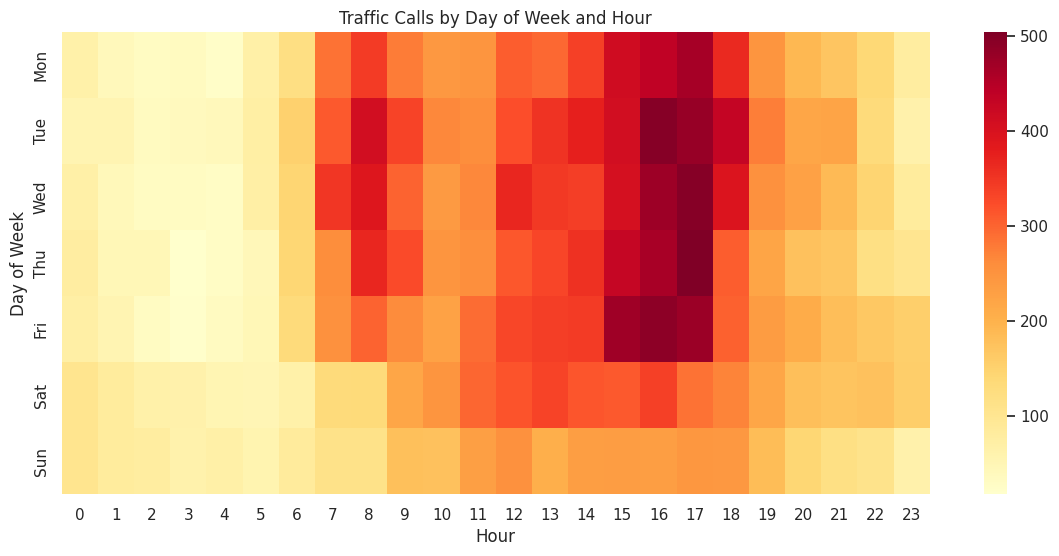

In [56]:
traffic_df = df_clean[df_clean["Reason"] == "Traffic"]

traffic_day_hour = traffic_df.pivot_table(
    index="DayOfWeek",
    columns="Hour",
    values="title",
    aggfunc="count"
)

plt.figure(figsize=(14, 6))
sns.heatmap(traffic_day_hour, cmap="YlOrRd")
plt.title("Traffic Calls by Day of Week and Hour")
plt.xlabel("Hour")
plt.ylabel("Day of Week")
plt.show()

## 57. Analyze EMS Calls by Day and Hour

### Request
Create a heatmap only for EMS calls using day of week and hour.

### Why we do this
EMS calls are usually the largest category, so we analyze their time pattern separately.

/tmp/ipykernel_3489/1863386950.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  ems_day_hour = ems_df.pivot_table(


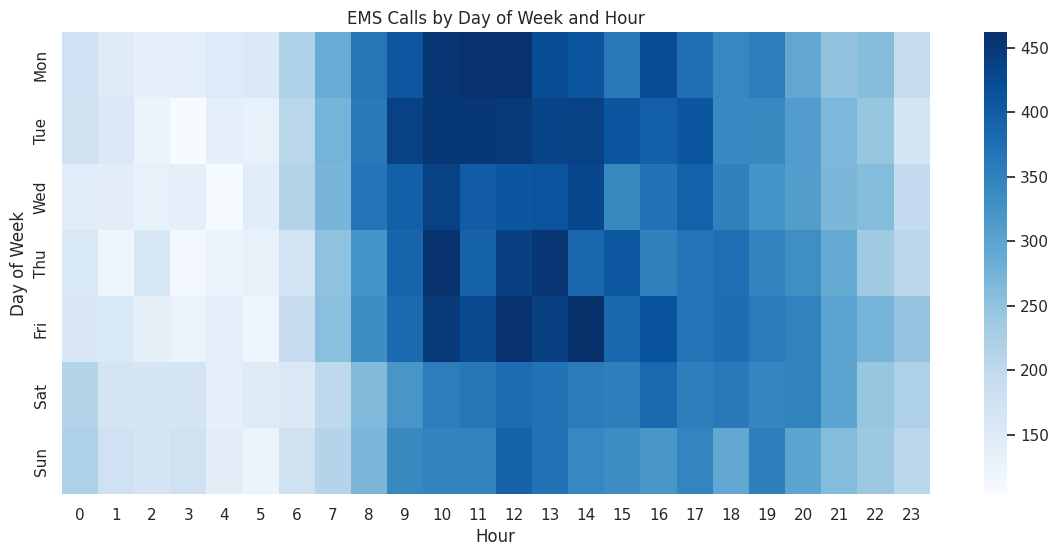

In [57]:
ems_df = df_clean[df_clean["Reason"] == "EMS"]

ems_day_hour = ems_df.pivot_table(
    index="DayOfWeek",
    columns="Hour",
    values="title",
    aggfunc="count"
)

plt.figure(figsize=(14, 6))
sns.heatmap(ems_day_hour, cmap="Blues")
plt.title("EMS Calls by Day of Week and Hour")
plt.xlabel("Hour")
plt.ylabel("Day of Week")
plt.show()

## 58. Analyze Fire Calls by Day and Hour

### Request
Create a heatmap only for Fire calls using day of week and hour.

### Why we do this
Fire calls may have different patterns from EMS and Traffic calls.

/tmp/ipykernel_3489/2702969481.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  fire_day_hour = fire_df.pivot_table(


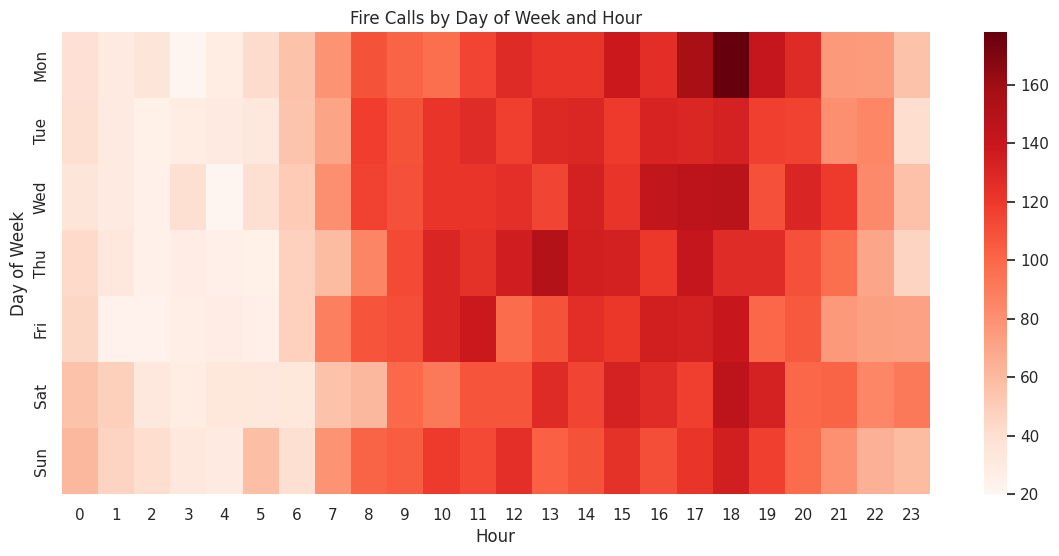

In [58]:
fire_df = df_clean[df_clean["Reason"] == "Fire"]

fire_day_hour = fire_df.pivot_table(
    index="DayOfWeek",
    columns="Hour",
    values="title",
    aggfunc="count"
)

plt.figure(figsize=(14, 6))
sns.heatmap(fire_day_hour, cmap="Reds")
plt.title("Fire Calls by Day of Week and Hour")
plt.xlabel("Hour")
plt.ylabel("Day of Week")
plt.show()

# Text and Address Analysis

## 59. Most Common Addresses

### Request
Find the top 10 addresses with the highest number of 911 calls.

### Why we do this
Some locations may appear many times because they are busy intersections, public places, or repeated emergency locations.

In [59]:
top_addresses = df_clean["addr"].value_counts().head(10)
top_addresses

addr
SHANNONDELL DR & SHANNONDELL BLVD    938
Unknown                              519
MAIN ST & OLD SUMNEYTOWN PIKE        390
THE FAIRWAY  & RYDAL RD              260
GULPH RD & KIRK AVE                  235
EVERGREEN RD & W LIGHTCAP RD         232
BLACK ROCK RD & S TRAPPE RD          219
GERMANTOWN PIKE & HANNAH AVE         210
EAGLEVILLE RD & SUNDERLAND DR        209
DAVISVILLE RD & PENNYPACK RD         203
Name: count, dtype: int64

## 60. Visualize Most Common Addresses

### Request
Create a horizontal bar chart for the top 10 addresses.

### Why we do this
Address names can be long, so horizontal bars make the chart readable.

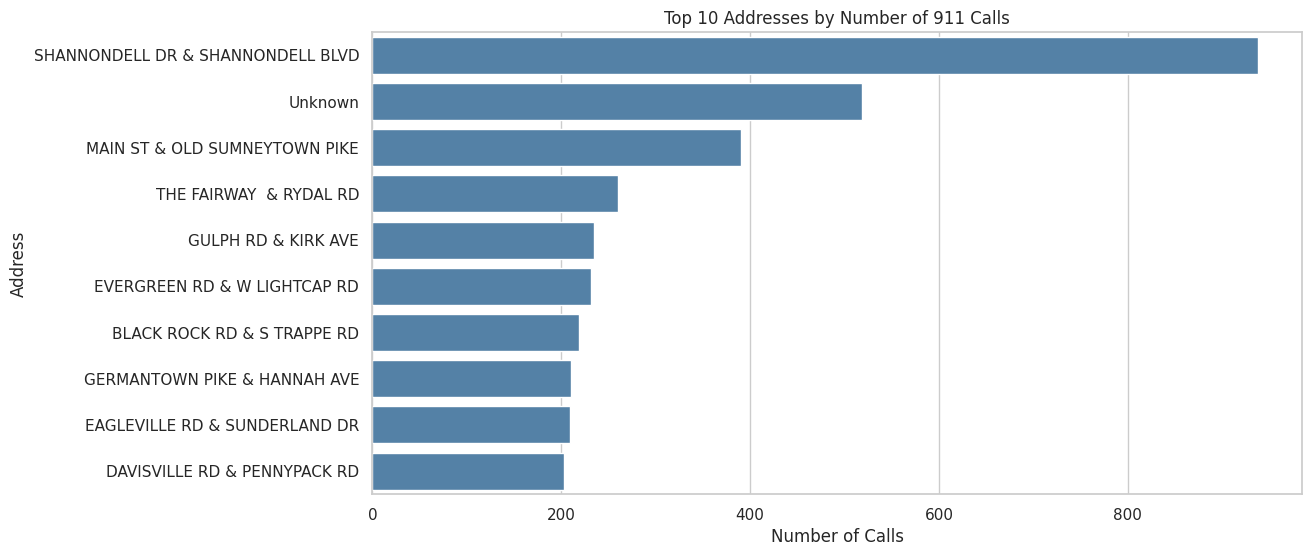

In [60]:
top_addresses_df = top_addresses.reset_index()
top_addresses_df.columns = ["address", "call_count"]

plt.figure(figsize=(12, 6))
sns.barplot(data=top_addresses_df, y="address", x="call_count", color="steelblue")
plt.title("Top 10 Addresses by Number of 911 Calls")
plt.xlabel("Number of Calls")
plt.ylabel("Address")
plt.show()

## 61. Most Common Description Texts

### Request
Find the most common values in the `desc` column.

### Why we do this
The description column contains detailed call information. Repeated descriptions may show duplicated or repeated event patterns.

In [61]:
df_clean["desc"].value_counts().head(10)

desc
GREEN ST & E BASIN ST;  NORRISTOWN; Station 308A; 2016-05-10 @ 20:23:26;                  4
SUSQUEHANNA RD & E BUTLER PIKE; UPPER DUBLIN; 2016-05-13 @ 12:15:59;                      3
N GULPH RD; UPPER MERION; 2015-12-12 @ 21:09:39-Station:STA47;                            3
PARK LN & VALLEY LN;  LOWER PROVIDENCE; Station 322A; 2015-12-13 @ 00:22:03;              2
BETHLEHEM PIKE & PENLLYN PIKE; LOWER GWYNEDD; 2016-06-06 @ 15:48:53;                      2
MT CARMEL AVE & ROBERTS AVE;  CHELTENHAM; Station 358A; 2016-06-06 @ 15:48:23;            2
CONSHOHOCKEN STATE RD & E CITY AVE;  LOWER MERION; Station 313; 2016-05-13 @ 12:20:36;    2
MAIN ST & SWEDE ST;  NORRISTOWN; Station 308A; 2016-04-08 @ 19:09:15;                     2
MARKLEY ST; NORRISTOWN; 2016-05-13 @ 10:37:47-Station:STA27;                              2
RT422  & PAWLINGS RD OVERPASS; LOWER PROVIDENCE; 2015-12-13 @ 08:56:23;                   2
Name: count, dtype: int64

# Summary Tables

## 62. Create a Summary Table by Reason

### Request
Create a table showing count, percentage, top call type, and busiest hour for each reason.

### Why we do this
A summary table combines multiple insights into one final result.

In [62]:
summary_reason = df_clean.groupby("Reason").agg(
    total_calls=("title", "count"),
    unique_call_types=("CallType", "nunique"),
    most_common_township=("twp", lambda x: x.value_counts().index[0]),
    busiest_hour=("Hour", lambda x: x.value_counts().index[0])
).reset_index()

summary_reason["percentage"] = (summary_reason["total_calls"] / len(df_clean) * 100).round(2)

most_common_call_type = (
    df_clean
    .groupby("Reason")["CallType"]
    .agg(lambda x: x.value_counts().index[0])
    .reset_index(name="most_common_call_type")
)

summary_reason = summary_reason.merge(most_common_call_type, on="Reason")
summary_reason = summary_reason[
    ["Reason", "total_calls", "percentage", "unique_call_types", "most_common_call_type", "most_common_township", "busiest_hour"]
]

summary_reason

,Reason,total_calls,percentage,unique_call_types,most_common_call_type,most_common_township,busiest_hour
0,EMS,48877,49.13,68,RESPIRATORY EMERGENCY,NORRISTOWN,12
1,Fire,14920,15.00,35,FIRE ALARM,LOWER MERION,18
2,Traffic,35695,35.88,7,VEHICLE ACCIDENT -,LOWER MERION,17


## 63. Create a Summary Table by Township

### Request
Create a table for the top 10 townships with total calls, EMS calls, Fire calls, and Traffic calls.

### Why we do this
This gives a compact township-level emergency profile.

In [63]:
township_reason_table = pd.crosstab(df_clean["twp"], df_clean["Reason"])
township_reason_table["Total"] = township_reason_table.sum(axis=1)

top_township_summary = township_reason_table.sort_values("Total", ascending=False).head(10)
top_township_summary

Reason,EMS,Fire,Traffic,Total
twp,,,,
LOWER MERION,3171,1548,3724,8443
ABINGTON,3043,940,1994,5977
NORRISTOWN,3858,777,1255,5890
UPPER MERION,2065,663,2499,5227
CHELTENHAM,2098,674,1803,4575
POTTSTOWN,2635,615,896,4146
UPPER MORELAND,1733,392,1309,3434
LOWER PROVIDENCE,2026,325,874,3225
PLYMOUTH,1274,442,1442,3158


## 64. Visualize Township Reason Breakdown

### Request
Create a stacked bar chart for the top 10 townships by reason.

### Why we do this
A stacked chart shows not only total calls, but also the composition of EMS, Fire, and Traffic calls.

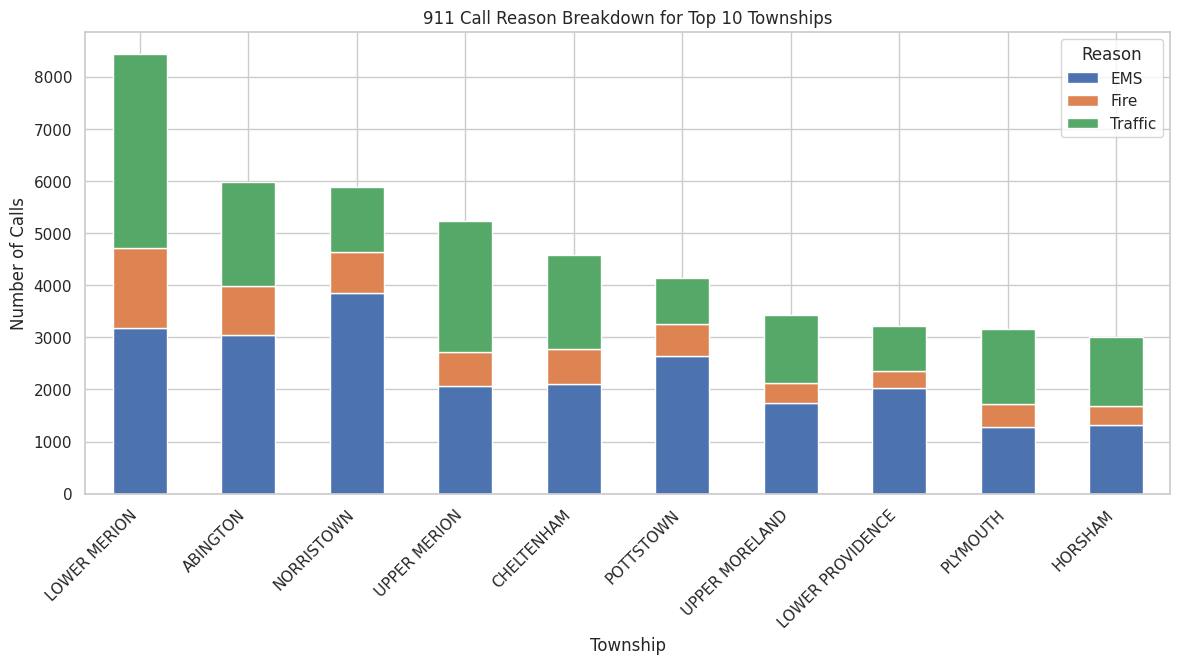

In [64]:
top_township_summary[["EMS", "Fire", "Traffic"]].plot(
    kind="bar",
    stacked=True,
    figsize=(14, 6)
)

plt.title("911 Call Reason Breakdown for Top 10 Townships")
plt.xlabel("Township")
plt.ylabel("Number of Calls")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Reason")
plt.show()

# Optional Feature Engineering for Machine Learning Preparation

## 65. Create a Clean Analysis Dataset

### Request
Select useful columns and save a cleaned dataset.

### Why we do this
After cleaning and feature engineering, we often create a final dataset that can be used for future analysis or machine learning.

In [65]:
analysis_columns = [
    "lat", "lng", "zip", "twp", "addr",
    "title", "Reason", "CallType",
    "timeStamp", "Date", "Year", "Month", "DayOfWeek", "Hour", "TimePeriod", "Weekend"
]

analysis_df = df_clean[analysis_columns].copy()

analysis_df.head()

,lat,lng,zip,twp,addr,title,Reason,CallType,timeStamp,Date,Year,Month,DayOfWeek,Hour,TimePeriod,Weekend
0,40.30,-75.58,19525,NEW HANOVER,REINDEER CT & DEAD END,EMS: BACK PAINS/INJURY,EMS,BACK PAINS/INJURY,2015-12-10 17:40:00,2015-12-10,2015,12,Thu,17,Evening,False
1,40.26,-75.26,19446,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,EMS: DIABETIC EMERGENCY,EMS,DIABETIC EMERGENCY,2015-12-10 17:40:00,2015-12-10,2015,12,Thu,17,Evening,False
2,40.12,-75.35,19401,NORRISTOWN,HAWS AVE,Fire: GAS-ODOR/LEAK,Fire,GAS-ODOR/LEAK,2015-12-10 17:40:00,2015-12-10,2015,12,Thu,17,Evening,False
3,40.12,-75.34,19401,NORRISTOWN,AIRY ST & SWEDE ST,EMS: CARDIAC EMERGENCY,EMS,CARDIAC EMERGENCY,2015-12-10 17:40:01,2015-12-10,2015,12,Thu,17,Evening,False
4,40.25,-75.60,<NA>,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,EMS: DIZZINESS,EMS,DIZZINESS,2015-12-10 17:40:01,2015-12-10,2015,12,Thu,17,Evening,False


## 66. Export Cleaned Dataset

### Request
Export the cleaned dataset to a new CSV file.

### Why we do this
This allows us to reuse the cleaned version without repeating all preprocessing steps.

In [66]:
analysis_df.to_csv("911_cleaned_analysis.csv", index=False)
print("Cleaned file saved as: 911_cleaned_analysis.csv")

Cleaned file saved as: 911_cleaned_analysis.csv


# Final Insights

## Main Conclusions

From this analysis, we can conclude:

1. The dataset contains real missing values, especially in the `zip` column.
2. EMS is the most common broad reason for 911 calls.
3. Detailed call types give better insight than broad categories alone.
4. Call volume changes by hour, day of week, and month.
5. Heatmaps are very useful for finding peak emergency periods.
6. Location analysis shows where calls are geographically concentrated.
7. Township-level analysis helps compare areas with high emergency activity.

## Skills Practiced

In this notebook, we practiced:

- Reading CSV files with Pandas
- Inspecting data with `.head()`, `.info()`, `.describe()`, `.shape`
- Handling missing values
- Converting strings to datetime
- Creating new columns with string and datetime methods
- Using `groupby`, `value_counts`, `pivot_table`, and `crosstab`
- Creating bar charts, countplots, line plots, scatter plots, heatmaps, and clustermaps
- Exporting cleaned data